# 📈 Simple Linear Regression — Complete Guide (Math, statsmodels, scikit-learn & a Real-Life Case Study)

**Simple** linear regression = **one predictor $x$** and one response $y$. It is the foundation of all regression: everything can be seen in a 2-D picture, every formula can be derived by hand, and every idea (cost functions, inference, diagnostics, over-fitting) carries over to bigger models.

We implement everything **three ways**: from scratch (NumPy), with **statsmodels** (statistical inference) and with **scikit-learn** (machine-learning workflow), and finish with an end-to-end **business case study**.

### Table of contents
| # | Section | What you will learn |
|---|---------|--------------------|
| 0 | Setup | Libraries & plotting style |
| 1 | Intuition | Model, terms, "which line is best?" |
| 2 | Cost / loss functions | SSE, MSE, RMSE, MAE, MAPE, Huber, R², adjusted R², cost surface, outlier sensitivity |
| 3 | Solving for the coefficients | Calculus derivation, Normal Equation, geometry (projection), Gradient Descent, SGD |
| 4 | Statistical inference | Variance decomposition, standard errors, t-test, F-test, confidence & prediction intervals, AIC/BIC |
| 5 | Special topics of *simple* regression | Correlation ↔ slope ↔ R², Anscombe's quartet, regression to the mean, y-on-x vs x-on-y, measurement error, no-intercept model, what makes the slope precise |
| 6 | Assumptions & diagnostics | Linearity, independence, equal variance, normality, leverage, Cook's distance |
| 7 | **statsmodels** | Reading `summary()` line by line, formulas, robust SEs, prediction intervals |
| 8 | **scikit-learn** | `LinearRegression`, pipelines, cross-validation, SGDRegressor, comparing all methods |
| 9 | When a straight line isn't enough | Log / log-log transformations, elasticity, curvature |
| 10 | 📣 **Real-life case study** | Advertising spend → sales: EDA, modelling, outliers, heteroscedasticity, WLS, hypothesis test on ROI, prediction intervals, budget planner |
| 11 | Cheat-sheet | Formulas, pitfalls, exercises |

> **Requirements:** `pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels`
> Run top-to-bottom; every random experiment uses a fixed seed.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# statsmodels is used in Section 7 and in the case study
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
except ImportError:
    print("statsmodels not found -> run: pip install statsmodels")

plt.rcParams.update({
    "figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Setup complete ✅")

statsmodels not found -> run: pip install statsmodels
Setup complete ✅


## 1. What is Linear Regression? (Intuition)

**Regression** = predicting a *continuous number* (price, score, temperature, sales …) from one or more inputs.

### The model
For **one** input (simple linear regression):

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i
$$

| Symbol | Name | Meaning |
|---|---|---|
| $y_i$ | response / target | what we want to predict |
| $x_i$ | predictor / feature | what we use to predict |
| $\beta_0$ | intercept | predicted $y$ when $x=0$ |
| $\beta_1$ | slope | **average change in $y$ for a 1-unit increase in $x$** |
| $\varepsilon_i$ | error / noise | everything the line cannot explain (other variables, randomness, measurement error) |

For **many** inputs (multiple linear regression):

$$
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip} + \varepsilon_i
\quad\Longleftrightarrow\quad
\mathbf{y} = \mathbf{X}\boldsymbol\beta + \boldsymbol\varepsilon
$$

### Two important clarifications
* **"Linear" means linear in the *parameters* $\beta$**, not in $x$. The model $y=\beta_0+\beta_1x+\beta_2x^2$ is still a *linear* regression (it is linear in $\beta$).
* **Population vs. sample.** The true $\beta$'s are unknown constants. We compute *estimates* $\hat\beta$ from data. The fitted line is $\hat y = \hat\beta_0+\hat\beta_1 x$, and the **residual** is $e_i = y_i-\hat y_i$ (the observed error). Residuals $e_i$ are *estimates* of the unobservable errors $\varepsilon_i$.

### Running example
A student's exam score vs. hours studied (synthetic data, true relationship: `score = 35 + 5.5 × hours + noise`).

,hours,score
0,7.9656,83.2703
1,4.9499,65.4834
2,8.7274,79.0075
3,7.2763,76.4127
4,1.8476,45.8619


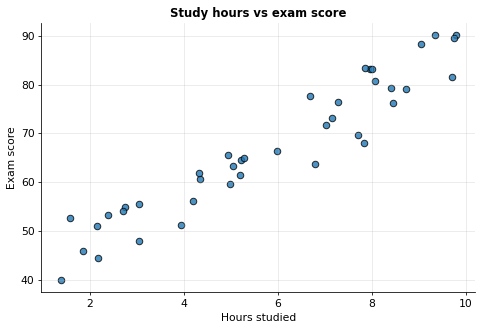

In [2]:
rng = np.random.default_rng(42)
n = 40
hours = rng.uniform(1, 10, n)
score = 35 + 5.5 * hours + rng.normal(0, 6, n)      # true beta0=35, true beta1=5.5, noise sd=6
df_study = pd.DataFrame({"hours": hours, "score": score})

x = df_study["hours"].values
y = df_study["score"].values
display(df_study.head())

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, edgecolor="k", alpha=.8)
ax.set(xlabel="Hours studied", ylabel="Exam score", title="Study hours vs exam score")
plt.show()

### Which line is "best"?
Infinitely many lines can be drawn through this cloud. Let's compare three of them by adding up how far each is from the data (sum of squared vertical distances, **SSE**).

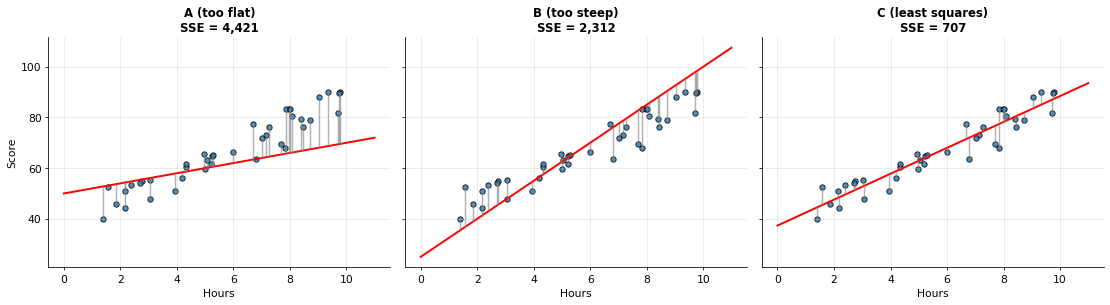

In [3]:
b1_hat, b0_hat = np.polyfit(x, y, 1)      # least-squares line (we derive this by hand in Section 3)
def sse(b0, b1): return np.sum((y - (b0 + b1 * x))**2)

candidates = {"A (too flat)": (50, 2.0), "B (too steep)": (25, 7.5), "C (least squares)": (b0_hat, b1_hat)}
xs = np.linspace(0, 11, 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (name, (b0, b1)) in zip(axes, candidates.items()):
    ax.scatter(x, y, s=30, edgecolor="k", alpha=.8)
    ax.plot(xs, b0 + b1 * xs, "r", lw=2)
    ax.vlines(x, y, b0 + b1 * x, colors="grey", alpha=.6)
    ax.set_title(f"{name}\nSSE = {sse(b0, b1):,.0f}")
    ax.set_xlabel("Hours")
axes[0].set_ylabel("Score")
plt.tight_layout(); plt.show()

**Take-away:** the "best" line is the one that makes the *total error* as small as possible. To make that precise we must choose an **error measure** – a *cost function* (also called *loss* or *objective*). That is the next section.

## 2. Cost (Loss) Functions & Evaluation Metrics

### 2.1 Residual
$$e_i = y_i - \hat y_i \qquad(\text{actual} - \text{predicted})$$
Positive residual → model *under*-predicted; negative → *over*-predicted.

If we simply summed residuals, positives and negatives would cancel (in OLS they sum to exactly 0!). So we need to make errors non-negative first:

### 2.2 The family of cost functions

| Name | Formula | Units | Key property |
|---|---|---|---|
| **SSE / RSS** (Sum of Squared Errors) | $\displaystyle \sum_{i=1}^n e_i^2$ | $y^2$ | The quantity OLS minimises |
| **MSE** (Mean Squared Error) | $\displaystyle \frac1n\sum e_i^2$ | $y^2$ | Average squared error; smooth & convex |
| **RMSE** | $\displaystyle \sqrt{\text{MSE}}$ | $y$ | Same units as $y$ ("typical error size", penalises big errors) |
| **MAE** (Mean Absolute Error) | $\displaystyle \frac1n\sum \lvert e_i\rvert$ | $y$ | Robust to outliers, not differentiable at 0 |
| **MAPE** | $\displaystyle \frac{100}{n}\sum \left\lvert\frac{e_i}{y_i}\right\rvert$ | % | Scale-free; breaks when $y_i\approx0$ |
| **Huber** (parameter $\delta$) | $\begin{cases}\tfrac12 e^2 & \lvert e\rvert\le\delta\\ \delta(\lvert e\rvert-\tfrac12\delta) & \lvert e\rvert>\delta\end{cases}$ | $y^2$/$y$ | Quadratic near 0, linear in the tails: best of both worlds |
| **Training objective used in gradient descent** | $\displaystyle J(\boldsymbol\beta)=\frac{1}{2n}\sum e_i^2$ | – | The ½ just cancels the 2 when differentiating |

### 2.3 Why *squared* error? (three good reasons)
1. **Calculus-friendly** – smooth, differentiable everywhere, and **convex** (a single bowl-shaped minimum, no local traps).
2. **Closed-form solution** – setting the gradient to zero gives the Normal Equation (Section 3).
3. **Statistical justification (Maximum Likelihood).** If errors are Gaussian, $\varepsilon_i\sim\mathcal N(0,\sigma^2)$, the likelihood is
$$
L(\boldsymbol\beta,\sigma^2)=\prod_i\frac1{\sqrt{2\pi\sigma^2}}\exp\!\Big(-\frac{(y_i-\mathbf x_i^\top\boldsymbol\beta)^2}{2\sigma^2}\Big)
\;\Rightarrow\;
\ell=-\frac n2\ln(2\pi\sigma^2)-\frac1{2\sigma^2}\underbrace{\sum_i (y_i-\mathbf x_i^\top\boldsymbol\beta)^2}_{\text{SSE}}
$$
Maximising $\ell$ over $\boldsymbol\beta$ is *exactly* minimising SSE. **OLS = MLE under Gaussian noise.** (Likewise, Laplace-distributed errors ⇒ minimising MAE.)
Also, the **Gauss–Markov theorem** says OLS is the *Best Linear Unbiased Estimator (BLUE)* under mild assumptions (Section 6).

### 2.4 Shapes of the losses
The picture below shows how each loss treats an error of size $e$, and the *gradient* (how hard it "pushes" the model to fix that error).

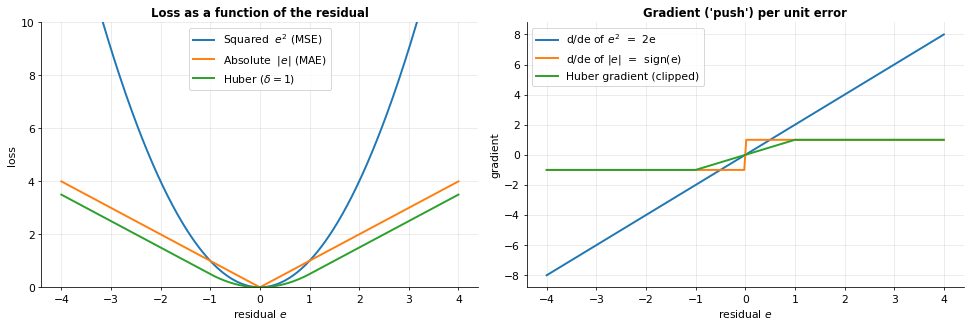

In [4]:
r = np.linspace(-4, 4, 401)
def huber(r, d=1.0): return np.where(np.abs(r) <= d, 0.5 * r**2, d * (np.abs(r) - 0.5 * d))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].plot(r, r**2, label="Squared  $e^2$ (MSE)", lw=2)
ax[0].plot(r, np.abs(r), label="Absolute  $|e|$ (MAE)", lw=2)
ax[0].plot(r, huber(r), label="Huber ($\\delta=1$)", lw=2)
ax[0].set(title="Loss as a function of the residual", xlabel="residual $e$", ylabel="loss", ylim=(0, 10)); ax[0].legend()

ax[1].plot(r, 2 * r, label="d/de of $e^2$  =  2e", lw=2)
ax[1].plot(r, np.sign(r), label="d/de of $|e|$  =  sign(e)", lw=2)
ax[1].plot(r, np.clip(r, -1, 1), label="Huber gradient (clipped)", lw=2)
ax[1].set(title="Gradient ('push') per unit error", xlabel="residual $e$", ylabel="gradient"); ax[1].legend()
plt.tight_layout(); plt.show()

**Reading the plot**
* **Squared loss:** an error of 4 costs 16, which is 4× the cost of an error of 2 (cost 4). Its gradient grows linearly with the error, so **one huge outlier dominates the fit**.
* **Absolute loss:** every unit of error costs the same; outliers have a bounded influence (gradient is only ±1) but the kink at 0 makes optimisation harder.
* **Huber:** behaves like squared loss for small errors (smooth) and like absolute loss for large ones (robust).

### 2.5 Residuals vs squared residuals on our data

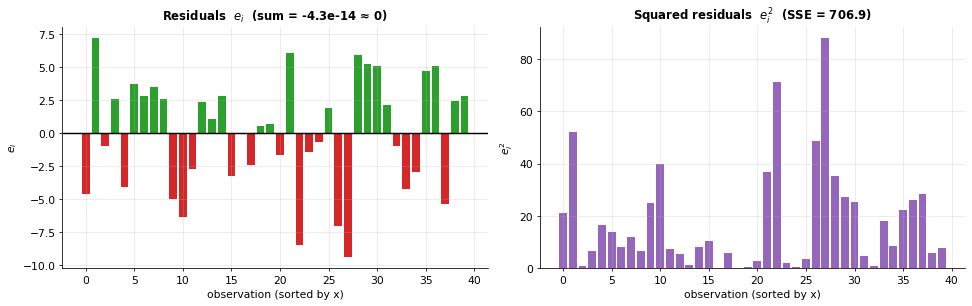

In [5]:
X1 = np.c_[np.ones(len(x)), x]
yhat = b0_hat + b1_hat * x
res = y - yhat

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
order = np.argsort(x)
ax[0].bar(range(len(x)), res[order], color=np.where(res[order] > 0, "tab:green", "tab:red"))
ax[0].axhline(0, color="k"); ax[0].set(title=f"Residuals  $e_i$  (sum = {res.sum():.1e} ≈ 0)", xlabel="observation (sorted by x)", ylabel="$e_i$")
ax[1].bar(range(len(x)), res[order]**2, color="tab:purple")
ax[1].set(title=f"Squared residuals  $e_i^2$  (SSE = {np.sum(res**2):,.1f})", xlabel="observation (sorted by x)", ylabel="$e_i^2$")
plt.tight_layout(); plt.show()

### 2.6 Goodness-of-fit metrics: $R^2$ and Adjusted $R^2$

Decompose the total variation of $y$ around its mean:

$$
\underbrace{\sum (y_i-\bar y)^2}_{\text{SST (total)}}=\underbrace{\sum(\hat y_i-\bar y)^2}_{\text{SSR (explained)}}+\underbrace{\sum (y_i-\hat y_i)^2}_{\text{SSE (unexplained)}}
$$

$$
R^2=\frac{\text{SSR}}{\text{SST}}=1-\frac{\text{SSE}}{\text{SST}}\in[0,1]
$$

*Interpretation:* "the fraction of the variance of $y$ explained by the model". $R^2=0$ means the model is no better than always predicting $\bar y$.

**Problem:** $R^2$ *never decreases* when you add a variable — even a random one. So use

$$
R^2_{adj}=1-(1-R^2)\frac{n-1}{n-p-1}
$$

which penalises the number of predictors $p$. (Here $n$ = sample size.)

Let's compute every metric by hand and verify with scikit-learn.

In [6]:
from sklearn import metrics

n_obs, p_pred = len(y), 1
SSE = np.sum(res**2)
SST = np.sum((y - y.mean())**2)
SSR = SST - SSE
MSE, RMSE = SSE / n_obs, np.sqrt(SSE / n_obs)
MAE  = np.mean(np.abs(res))
MAPE = np.mean(np.abs(res / y)) * 100
R2   = 1 - SSE / SST
R2adj = 1 - (1 - R2) * (n_obs - 1) / (n_obs - p_pred - 1)

table = pd.DataFrame({
    "by hand": [SSE, MSE, RMSE, MAE, MAPE, R2, R2adj],
    "scikit-learn": [np.nan, metrics.mean_squared_error(y, yhat), np.sqrt(metrics.mean_squared_error(y, yhat)),
                     metrics.mean_absolute_error(y, yhat), metrics.mean_absolute_percentage_error(y, yhat) * 100,
                     metrics.r2_score(y, yhat), np.nan]},
    index=["SSE", "MSE", "RMSE", "MAE", "MAPE (%)", "R²", "Adjusted R²"])
display(table)
print(f"SST = {SST:.1f} = SSR {SSR:.1f} + SSE {SSE:.1f}")

SST = 7603.5 = SSR 6896.6 + SSE 706.9


,by hand,scikit-learn
SSE,706.8917,NaN
MSE,17.6723,17.6723
RMSE,4.2038,4.2038
MAE,3.5675,3.5675
MAPE (%),5.5608,5.5608
R²,0.9070,0.9070
Adjusted R²,0.9046,NaN


### 2.7 The cost *surface* — why OLS has one clean answer

For simple regression the cost $J(\beta_0,\beta_1)$ is a function of two numbers, so we can literally see it. Because $J$ is a **quadratic** function of $\boldsymbol\beta$, its graph is a **convex bowl** with one global minimum — no local minima, no saddle traps. Gradient descent (Section 3.4) is just "rolling a ball down this bowl".

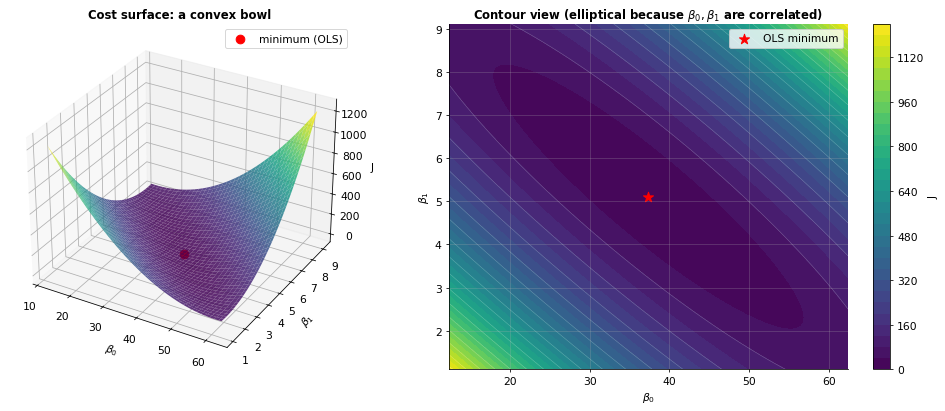

In [7]:
b0g = np.linspace(b0_hat - 25, b0_hat + 25, 120)
b1g = np.linspace(b1_hat - 4, b1_hat + 4, 120)
B0, B1 = np.meshgrid(b0g, b1g)
J = np.array([[np.mean((y - (a + b * x))**2) / 2 for a in b0g] for b in b1g])   # J = 1/(2n) * SSE

fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(B0, B1, J, cmap="viridis", alpha=.85, linewidth=0)
ax.scatter([b0_hat], [b1_hat], [J.min()], color="red", s=80, label="minimum (OLS)")
ax.set(xlabel=r"$\beta_0$", ylabel=r"$\beta_1$", zlabel="J", title="Cost surface: a convex bowl"); ax.legend()

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(B0, B1, J, levels=30, cmap="viridis")
ax2.contour(B0, B1, J, levels=15, colors="white", alpha=.3, linewidths=.5)
ax2.scatter([b0_hat], [b1_hat], color="red", s=120, marker="*", label="OLS minimum")
ax2.set(xlabel=r"$\beta_0$", ylabel=r"$\beta_1$", title="Contour view (elliptical because $\\beta_0,\\beta_1$ are correlated)"); ax2.legend()
plt.colorbar(cs, ax=ax2, label="J"); plt.tight_layout(); plt.show()

The **tilted ellipses** show that $\hat\beta_0$ and $\hat\beta_1$ trade off against each other: a steeper slope must be compensated by a lower intercept. That's why gradient descent on *unscaled* features crawls down a narrow valley (Section 3.4).

### 2.8 Outlier sensitivity: MSE vs MAE vs Huber
Add two bad points (a "high-scorer" recorded as 15 by mistake) and see which loss resists.

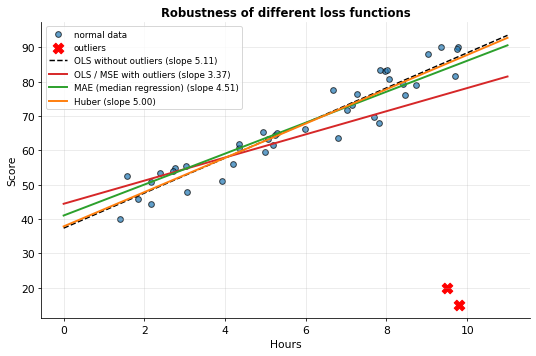

In [8]:
from scipy.optimize import minimize
from sklearn.linear_model import HuberRegressor

x_o = np.append(x, [9.5, 9.8]); y_o = np.append(y, [20, 15])          # two outliers at high x

b1_ols, b0_ols = np.polyfit(x_o, y_o, 1)
mae_obj = lambda b: np.mean(np.abs(y_o - (b[0] + b[1] * x_o)))
b_mae = minimize(mae_obj, [b0_ols, b1_ols], method="Nelder-Mead").x
hub = HuberRegressor(epsilon=1.35).fit(x_o.reshape(-1, 1), y_o)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x, y, s=35, edgecolor="k", alpha=.7, label="normal data")
ax.scatter(x_o[-2:], y_o[-2:], s=120, color="red", marker="X", label="outliers")
ax.plot(xs, b0_hat + b1_hat * xs, "k--", label=f"OLS without outliers (slope {b1_hat:.2f})")
ax.plot(xs, b0_ols + b1_ols * xs, "tab:red", lw=2, label=f"OLS / MSE with outliers (slope {b1_ols:.2f})")
ax.plot(xs, b_mae[0] + b_mae[1] * xs, "tab:green", lw=2, label=f"MAE (median regression) (slope {b_mae[1]:.2f})")
ax.plot(xs, hub.intercept_ + hub.coef_[0] * xs, "tab:orange", lw=2, label=f"Huber (slope {hub.coef_[0]:.2f})")
ax.set(xlabel="Hours", ylabel="Score", title="Robustness of different loss functions"); ax.legend(fontsize=9)
plt.show()

**Lesson:** squared error gets dragged toward outliers; MAE and Huber stay close to the true trend. Always *look at your data* and choose the loss that matches your problem (e.g. if a 10-unit error is **more than twice as bad** as a 5-unit error, squared loss is appropriate).

## 3. Finding the Best Coefficients

We want $\hat{\boldsymbol\beta}=\arg\min_{\boldsymbol\beta}\ \text{SSE}(\boldsymbol\beta)$. Four ways to get there:

1. Calculus, simple regression → closed-form formulas
2. Calculus, matrix form → **Normal Equation**
3. Geometry → **orthogonal projection**
4. Iterative → **Gradient Descent** (needed when data is huge or the model has no closed form)

### 3.1 Calculus for simple regression
$$
S(\beta_0,\beta_1)=\sum_{i}(y_i-\beta_0-\beta_1x_i)^2
$$
Set both partial derivatives to zero:

$$
\frac{\partial S}{\partial\beta_0}=-2\sum(y_i-\beta_0-\beta_1x_i)=0 \;\Rightarrow\; \boxed{\hat\beta_0=\bar y-\hat\beta_1\bar x}
$$
$$
\frac{\partial S}{\partial\beta_1}=-2\sum x_i(y_i-\beta_0-\beta_1x_i)=0
\;\Rightarrow\;
\boxed{\hat\beta_1=\frac{\sum(x_i-\bar x)(y_i-\bar y)}{\sum(x_i-\bar x)^2}=\frac{S_{xy}}{S_{xx}}=r_{xy}\,\frac{s_y}{s_x}}
$$

**Intuition**
* $\hat\beta_0=\bar y-\hat\beta_1\bar x$ ⇒ *the least-squares line always passes through the centroid $(\bar x,\bar y)$*.
* $\hat\beta_1=r\,s_y/s_x$ ⇒ the slope is the **correlation** rescaled to the units of $y$ per unit of $x$. If $x$ and $y$ are uncorrelated, the slope is 0.

In [9]:
x = df_study["hours"].values; y = df_study["score"].values
Sxx = np.sum((x - x.mean())**2)
Sxy = np.sum((x - x.mean()) * (y - y.mean()))
b1 = Sxy / Sxx
b0 = y.mean() - b1 * x.mean()
r_xy = np.corrcoef(x, y)[0, 1]

print(f"Closed form   : b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"np.polyfit    : b0 = {np.polyfit(x, y, 1)[1]:.4f}, b1 = {np.polyfit(x, y, 1)[0]:.4f}")
print(f"r * sy/sx     : b1 = {r_xy * y.std() / x.std():.4f}   (r = {r_xy:.4f})")
print(f"Passes through centroid? predicted at x̄ = {b0 + b1 * x.mean():.4f}  vs  ȳ = {y.mean():.4f}")
print("True (hidden) values: b0 = 35, b1 = 5.5  → our estimates are close, but not identical (sampling noise!)")

Closed form   : b0 = 37.3518, b1 = 5.1083
np.polyfit    : b0 = 37.3518, b1 = 5.1083
r * sy/sx     : b1 = 5.1083   (r = 0.9524)
Passes through centroid? predicted at x̄ = 66.9924  vs  ȳ = 66.9924
True (hidden) values: b0 = 35, b1 = 5.5  → our estimates are close, but not identical (sampling noise!)


### 3.2 Matrix form → the Normal Equation

Stack the data: $\mathbf y\in\mathbb R^{n}$, $\mathbf X\in\mathbb R^{n\times(p+1)}$ (first column of ones for the intercept), $\boldsymbol\beta\in\mathbb R^{p+1}$.

$$
S(\boldsymbol\beta)=(\mathbf y-\mathbf X\boldsymbol\beta)^\top(\mathbf y-\mathbf X\boldsymbol\beta)
=\mathbf y^\top\mathbf y-2\boldsymbol\beta^\top\mathbf X^\top\mathbf y+\boldsymbol\beta^\top\mathbf X^\top\mathbf X\boldsymbol\beta
$$

Gradient and Hessian:
$$
\nabla_{\boldsymbol\beta}S=-2\mathbf X^\top\mathbf y+2\mathbf X^\top\mathbf X\boldsymbol\beta=\mathbf 0
\;\Longrightarrow\;
\boxed{\mathbf X^\top\mathbf X\,\hat{\boldsymbol\beta}=\mathbf X^\top\mathbf y}
\;\Longrightarrow\;
\hat{\boldsymbol\beta}=(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y
$$
$$
\nabla^2 S=2\mathbf X^\top\mathbf X\succeq0 \;\Rightarrow\; \text{convex, so this stationary point is the global minimum.}
$$

**Conditions:** $\mathbf X^\top\mathbf X$ must be invertible ⇔ the columns of $\mathbf X$ are linearly independent (no *perfect multicollinearity*) and $n>p$.

**Numerical note:** in practice we *don't* invert $\mathbf X^\top\mathbf X$ (it squares the condition number). Libraries use **QR** or **SVD** factorisations (`np.linalg.lstsq`, `scikit-learn`, `statsmodels` via pseudo-inverse).

In [10]:
X = np.c_[np.ones(len(x)), x]                       # design matrix [1, x]

beta_inv   = np.linalg.inv(X.T @ X) @ X.T @ y       # textbook formula (fine for teaching)
beta_solve = np.linalg.solve(X.T @ X, X.T @ y)      # better: solve the linear system
beta_lstsq = np.linalg.lstsq(X, y, rcond=None)[0]   # best: SVD-based least squares
beta_pinv  = np.linalg.pinv(X) @ y                  # Moore-Penrose pseudo-inverse

print(pd.DataFrame([beta_inv, beta_solve, beta_lstsq, beta_pinv], columns=["b0", "b1"],
                   index=["inverse", "solve", "lstsq (SVD)", "pinv"]))
print("\nCondition number of X'X :", f"{np.linalg.cond(X.T @ X):,.1f}", "  vs  of X :", f"{np.linalg.cond(X):,.1f}  (X'X squares it!)")

                 b0     b1
inverse     37.3518 5.1083
solve       37.3518 5.1083
lstsq (SVD) 37.3518 5.1083
pinv        37.3518 5.1083

Condition number of X'X : 255.8   vs  of X : 16.0  (X'X squares it!)


### 3.3 Geometric view: OLS is an *orthogonal projection*

Think of $\mathbf y$ as a **vector in $n$-dimensional space**. All predictions $\mathbf X\boldsymbol\beta$ live in the **column space** of $\mathbf X$ (a flat subspace). The best prediction $\hat{\mathbf y}$ is the point in that subspace **closest** to $\mathbf y$ — which is the *perpendicular projection*:

$$
\hat{\mathbf y}=\mathbf H\mathbf y,\qquad \mathbf H=\mathbf X(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\ \ (\text{"hat matrix"})
$$

The residual vector $\mathbf e=\mathbf y-\hat{\mathbf y}$ is **perpendicular** to every column of $\mathbf X$:  $\ \mathbf X^\top\mathbf e=\mathbf 0$. Two direct consequences: residuals sum to zero (the column of ones) and residuals are uncorrelated with every predictor. This right-angle also gives Pythagoras: $\|\mathbf y\|^2=\|\hat{\mathbf y}\|^2+\|\mathbf e\|^2$ — the SST = SSR + SSE identity.

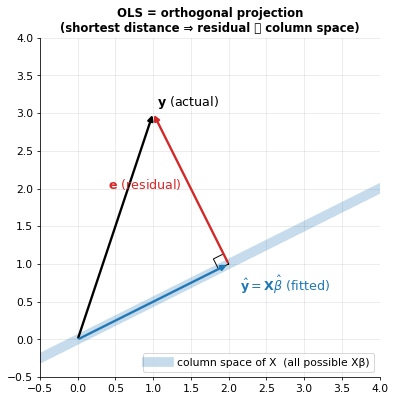

X'e  (should be ~0)              : [-0. -0.]
Trace of H = number of params    : 2.0
H is idempotent (H@H == H)?      : True
Pythagoras: |y|² = |ŷ|² + |e|²   : 187122.695 = 187122.695


In [11]:
# 2-D cartoon: one column of X spans a line; y is projected onto it
a = np.array([2.0, 1.0]); yv = np.array([1.0, 3.0])
proj = (a @ yv) / (a @ a) * a
ev = yv - proj

fig, ax = plt.subplots(figsize=(6.8, 6.3))
t = np.array([-0.5, 4]); ax.plot(t * a[0], t * a[1], color="tab:blue", alpha=.25, lw=10, label="column space of X  (all possible Xβ)")
arrow = lambda p, q, c, lab: ax.annotate("", xy=q, xytext=p, arrowprops=dict(arrowstyle="-|>", lw=2.4, color=c))
arrow((0, 0), yv, "k", "y");           ax.text(*(yv + [0.05, 0.1]), r"$\mathbf{y}$ (actual)", fontsize=13)
arrow((0, 0), proj, "tab:blue", "");    ax.text(*(proj + [0.15, -0.35]), r"$\hat{\mathbf{y}}=\mathbf{X}\hat\beta$ (fitted)", fontsize=13, color="tab:blue")
arrow(proj, yv, "tab:red", "");         ax.text(*(proj + ev / 2 + [-1.1, 0]), r"$\mathbf{e}$ (residual)", fontsize=13, color="tab:red")
u, v = a / np.linalg.norm(a), ev / np.linalg.norm(ev); s = .15                      # right-angle mark
sq = np.array([proj, proj - s * u, proj - s * u + s * v, proj + s * v, proj]); ax.plot(sq[:, 0], sq[:, 1], "k", lw=1)
ax.set(xlim=(-0.5, 4), ylim=(-0.5, 4), aspect="equal", title="OLS = orthogonal projection\n(shortest distance ⇒ residual ⟂ column space)"); ax.legend(loc="lower right")
plt.show()

# Numerical verification on our real data
H = X @ np.linalg.inv(X.T @ X) @ X.T
e = y - H @ y
print("X'e  (should be ~0)              :", np.round(X.T @ e, 8))
print("Trace of H = number of params    :", round(np.trace(H), 6))
print("H is idempotent (H@H == H)?      :", np.allclose(H @ H, H))
print("Pythagoras: |y|² = |ŷ|² + |e|²   :", round(y @ y, 3), "=", round((H @ y) @ (H @ y) + e @ e, 3))

### 3.4 Gradient Descent (GD)

When $p$ is huge (millions of features), $n$ is enormous, or the model is not linear, we can't solve a linear system, so we **walk downhill** on the cost surface:

$$
J(\boldsymbol\theta)=\frac1{2n}\|\mathbf X\boldsymbol\theta-\mathbf y\|^2,\qquad
\nabla J=\frac1n\mathbf X^\top(\mathbf X\boldsymbol\theta-\mathbf y)
$$
$$
\boxed{\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta\,\nabla J(\boldsymbol\theta_t)}
$$

* $\eta$ = **learning rate**. Too small ⇒ painfully slow; too large ⇒ overshoots and **diverges**.
* For this quadratic cost the Hessian is $\mathbf H_J=\mathbf X^\top\mathbf X/n$. GD converges iff $\eta<2/\lambda_{max}$, and the speed is governed by the **condition number** $\lambda_{max}/\lambda_{min}$ — that's why we **standardise features** first (makes the contours circular).

Per-parameter update (what the gradient actually looks like):
$$
\theta_j\leftarrow\theta_j-\eta\cdot\frac1n\sum_i (\hat y_i-y_i)\,x_{ij}
$$

GD  (η=0.1, 300 iters): b0 = 37.3518, b1 = 5.1083
OLS closed form       : b0 = 37.3518, b1 = 5.1083


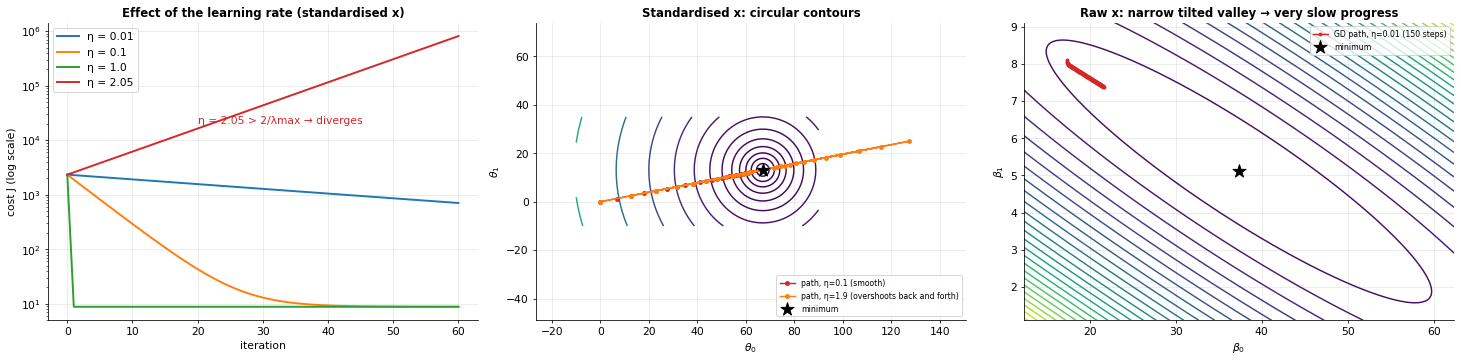

In [12]:
def gradient_descent(X, y, lr=0.1, epochs=100, theta0=None):
    n = len(y)
    theta = np.zeros(X.shape[1]) if theta0 is None else np.array(theta0, float)
    th_hist, cost_hist = [theta.copy()], []
    for _ in range(epochs):
        err = X @ theta - y
        cost_hist.append(err @ err / (2 * n))
        theta = theta - lr * (X.T @ err) / n
        th_hist.append(theta.copy())
    cost_hist.append(((X @ theta - y)**2).sum() / (2 * n))
    return theta, np.array(th_hist), np.array(cost_hist)

# Standardise x  (z = (x-mean)/sd) so that GD behaves well
mu, sd = x.mean(), x.std()
Xz = np.c_[np.ones(len(x)), (x - mu) / sd]

lrs = [0.01, 0.1, 1.0, 2.05]
fig, ax = plt.subplots(1, 3, figsize=(21, 5.3))
for lr in lrs:
    th, hist, cost = gradient_descent(Xz, y, lr=lr, epochs=60)
    ax[0].semilogy(cost, label=f"η = {lr}", lw=2)
ax[0].set(xlabel="iteration", ylabel="cost J (log scale)", title="Effect of the learning rate (standardised x)"); ax[0].legend()
ax[0].text(20, 2e4, "η = 2.05 > 2/λmax → diverges", color="tab:red")

# recover coefficients in original units:  y = th0 + th1*(x-mu)/sd  →  b1 = th1/sd, b0 = th0 - th1*mu/sd
th, hist, cost = gradient_descent(Xz, y, lr=0.1, epochs=300)
b1_gd, b0_gd = th[1] / sd, th[0] - th[1] * mu / sd
print(f"GD  (η=0.1, 300 iters): b0 = {b0_gd:.4f}, b1 = {b1_gd:.4f}")
print(f"OLS closed form       : b0 = {b0:.4f}, b1 = {b1:.4f}")

# Contour + paths in STANDARDISED space (contours are circles → gradient points straight at the minimum)
g0 = np.linspace(-10, 90, 150); g1 = np.linspace(-10, 35, 150)
G0, G1 = np.meshgrid(g0, g1)
JZ = np.array([[np.mean((y - (a + b * Xz[:, 1]))**2) / 2 for a in g0] for b in g1])
ax[1].contour(G0, G1, JZ, levels=np.logspace(0, 3.7, 18), cmap="viridis")
for lr, c in [(0.1, "tab:red"), (1.9, "tab:orange")]:
    _, h, _ = gradient_descent(Xz, y, lr=lr, epochs=25)
    ax[1].plot(h[:, 0], h[:, 1], "o-", color=c, ms=4, label=f"path, η={lr}" + (" (overshoots back and forth)" if lr > 1 else " (smooth)"))
ax[1].scatter(*th, marker="*", s=200, color="k", zorder=5, label="minimum")
ax[1].set_aspect("equal", adjustable="datalim")
ax[1].set(xlabel=r"$\theta_0$", ylabel=r"$\theta_1$", title="Standardised x: circular contours"); ax[1].legend(fontsize=8, loc="lower right")

# Same algorithm on the RAW (unscaled) parameters: elongated valley → slow zig-zag
_, h_raw, _ = gradient_descent(X, y, lr=0.01, epochs=150, theta0=[b0_hat - 20, b1_hat + 3])
ax[2].contour(B0, B1, J, levels=25, cmap="viridis")
ax[2].plot(h_raw[:, 0], h_raw[:, 1], "o-", color="tab:red", ms=3, label="GD path, η=0.01 (150 steps)")
ax[2].scatter(b0_hat, b1_hat, marker="*", s=200, color="k", zorder=5, label="minimum")
ax[2].set(xlabel=r"$\beta_0$", ylabel=r"$\beta_1$", title="Raw x: narrow tilted valley → very slow progress"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Feature scaling matters.** Compare GD with the *same* learning rate on raw vs. standardised $x$:

Condition number of X'X/n  raw: 255.8   standardised: 1.0


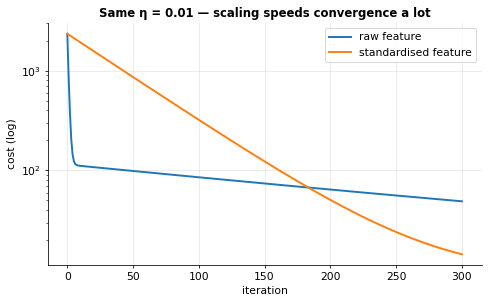

In [13]:
_, _, cost_scaled = gradient_descent(Xz, y, lr=0.01, epochs=300)
_, _, cost_raw    = gradient_descent(X,  y, lr=0.01, epochs=300)      # raw hours (1..10)
print("Condition number of X'X/n  raw:", f"{np.linalg.cond(X.T @ X / len(y)):.1f}", "  standardised:", f"{np.linalg.cond(Xz.T @ Xz / len(y)):.1f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(cost_raw, label="raw feature", lw=2); ax.semilogy(cost_scaled, label="standardised feature", lw=2)
ax.set(xlabel="iteration", ylabel="cost (log)", title="Same η = 0.01 — scaling speeds convergence a lot"); ax.legend(); plt.show()

### 3.5 Stochastic & mini-batch gradient descent
Instead of using all $n$ rows for each step, use **one** row (SGD) or a **small batch** (mini-batch). Each step is noisy but *much cheaper*, and it is how deep-learning models are trained.

| Variant | Rows per update | Path | Cost per epoch |
|---|---|---|---|
| Batch GD | all $n$ | smooth | 1 update |
| Mini-batch GD | e.g. 8–256 | slightly noisy | $n/b$ updates |
| SGD | 1 | very noisy | $n$ updates |

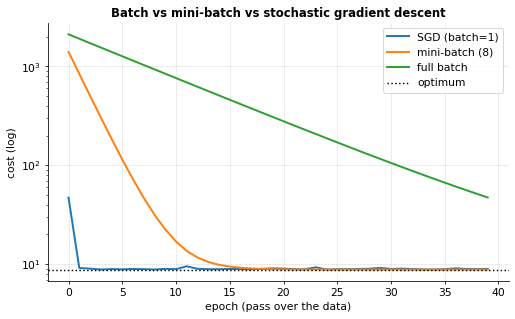

In [14]:
def sgd(X, y, lr=0.05, epochs=40, batch=1, seed=0):
    rng = np.random.default_rng(seed); n = len(y)
    theta = np.zeros(X.shape[1]); costs = []
    for _ in range(epochs):
        idx = rng.permutation(n)
        for s in range(0, n, batch):
            b = idx[s:s + batch]
            theta -= lr * X[b].T @ (X[b] @ theta - y[b]) / len(b)
        costs.append(((X @ theta - y)**2).sum() / (2 * n))
    return theta, np.array(costs)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for b, lab in [(1, "SGD (batch=1)"), (8, "mini-batch (8)"), (len(y), "full batch")]:
    _, c = sgd(Xz, y, lr=0.05, epochs=40, batch=b)
    ax.semilogy(c, lw=2, label=lab)
ax.axhline(cost.min(), color="k", ls=":", label="optimum")
ax.set(xlabel="epoch (pass over the data)", ylabel="cost (log)", title="Batch vs mini-batch vs stochastic gradient descent"); ax.legend(); plt.show()

## 4. Statistical Inference — *How sure are we?*

Getting $\hat\beta$ is only half the story. Because our data is a random sample, $\hat\beta$ would change with a new sample. Inference quantifies that uncertainty.

### 4.1 Distribution of the estimator
Under the classical assumptions ($\boldsymbol\varepsilon\sim\mathcal N(\mathbf 0,\sigma^2\mathbf I)$):

$$
\hat{\boldsymbol\beta}\sim\mathcal N\!\big(\boldsymbol\beta,\ \sigma^2(\mathbf X^\top\mathbf X)^{-1}\big),\qquad
\hat\sigma^2=s^2=\frac{\text{SSE}}{n-p-1}
$$
(we divide by $n-p-1$ = *residual degrees of freedom*, because $p+1$ parameters were estimated from the data — this makes $s^2$ unbiased).

* **Standard error:** $\text{SE}(\hat\beta_j)=\sqrt{s^2\,[(\mathbf X^\top\mathbf X)^{-1}]_{jj}}$. For simple regression $\text{SE}(\hat\beta_1)=s/\sqrt{S_{xx}}$ → *more spread in $x$, more data, less noise ⇒ more precise slope.*
* **t-test** for $H_0:\beta_j=0$: $\ t_j=\dfrac{\hat\beta_j}{\text{SE}(\hat\beta_j)}\sim t_{n-p-1}$. The **p-value** is the probability of a $|t|$ at least this large if the true coefficient were 0.
* **Confidence interval:** $\hat\beta_j\pm t_{1-\alpha/2,\,n-p-1}\cdot\text{SE}(\hat\beta_j)$.
* **F-test** (is the model useful *at all*?), $H_0:\beta_1=\dots=\beta_p=0$:
$$F=\frac{\text{SSR}/p}{\text{SSE}/(n-p-1)}\sim F_{p,\,n-p-1}$$
* **Information criteria** (for comparing models; *lower is better*): with $k=p+1$ parameters and Gaussian log-likelihood $\ell=-\frac n2[\ln(2\pi)+\ln(\text{SSE}/n)+1]$
$$\text{AIC}=2k-2\ell,\qquad \text{BIC}=k\ln n-2\ell$$
BIC penalises complexity more strongly than AIC.

Let's compute the full regression table **by hand**. In Section 7 we'll confirm that statsmodels gives identical numbers.

In [15]:
n = len(y); X = np.c_[np.ones(n), x]; p = 1
beta = np.linalg.solve(X.T @ X, X.T @ y)
resid = y - X @ beta
df_resid = n - p - 1
SSE = resid @ resid; SST = ((y - y.mean())**2).sum(); SSR = SST - SSE
s2 = SSE / df_resid
cov = s2 * np.linalg.inv(X.T @ X)
se = np.sqrt(np.diag(cov))
t_vals = beta / se
p_vals = 2 * stats.t.sf(np.abs(t_vals), df_resid)
t_crit = stats.t.ppf(0.975, df_resid)
ci_lo, ci_hi = beta - t_crit * se, beta + t_crit * se

coef_table = pd.DataFrame({"coef": beta, "std err": se, "t": t_vals, "P>|t|": p_vals, "[0.025": ci_lo, "0.975]": ci_hi}, index=["const", "hours"])
display(coef_table)

F = (SSR / p) / (SSE / df_resid); pF = stats.f.sf(F, p, df_resid)
llf = -n / 2 * (np.log(2 * np.pi) + np.log(SSE / n) + 1)
k = p + 1
summary_by_hand = pd.Series({"R²": SSR / SST, "Adj R²": 1 - (1 - SSR / SST) * (n - 1) / df_resid, "Residual std error (s)": np.sqrt(s2),
                             "F-statistic": F, "Prob(F)": pF, "Log-Likelihood": llf, "AIC": 2 * k - 2 * llf, "BIC": k * np.log(n) - 2 * llf})
display(summary_by_hand.to_frame("by hand"))

,coef,std err,t,P>|t|,[0.025,0.975]
const,37.3518,1.6837,22.1844,0.0000,33.9433,40.7602
hours,5.1083,0.2653,19.2546,0.0000,4.5712,5.6454


,by hand
R²,0.9070
Adj R²,0.9046
Residual std error (s),4.3131
F-statistic,370.7383
Prob(F),0.0000
Log-Likelihood,-114.1975
AIC,232.3950
BIC,235.7728


### 4.2 Pictures of the variance decomposition and the t-test

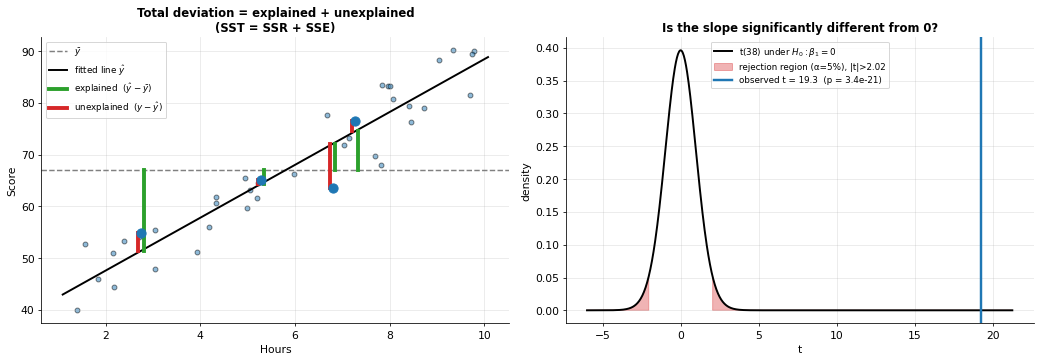

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.3))

# --- Left: decomposition of deviation for 4 points
pick = [3, 12, 25, 37]
ax[0].scatter(x, y, s=25, alpha=.5, edgecolor="k")
ax[0].axhline(y.mean(), color="grey", ls="--", label=r"$\bar y$")
xs_ = np.linspace(x.min() - .3, x.max() + .3, 50); ax[0].plot(xs_, beta[0] + beta[1] * xs_, "k", lw=2, label=r"fitted line $\hat y$")
for j, i in enumerate(pick):
    yh = beta[0] + beta[1] * x[i]
    ax[0].plot([x[i] + .06, x[i] + .06], [y.mean(), yh], color="tab:green", lw=4, label="explained  ($\\hat y-\\bar y$)" if j == 0 else None)
    ax[0].plot([x[i] - .06, x[i] - .06], [yh, y[i]], color="tab:red", lw=4, label="unexplained  ($y-\\hat y$)" if j == 0 else None)
    ax[0].scatter(x[i], y[i], s=90, color="tab:blue", zorder=5)
ax[0].set(xlabel="Hours", ylabel="Score", title="Total deviation = explained + unexplained\n(SST = SSR + SSE)"); ax[0].legend(fontsize=9)

# --- Right: t-distribution and the observed slope t-stat
tt = np.linspace(-6, max(abs(t_vals[1]) + 2, 8), 800)
ax[1].plot(tt, stats.t.pdf(tt, df_resid), "k", lw=2, label=f"t({df_resid}) under $H_0:\\beta_1=0$")
ax[1].fill_between(tt, stats.t.pdf(tt, df_resid), where=np.abs(tt) >= t_crit, color="tab:red", alpha=.35, label=f"rejection region (α=5%), |t|>{t_crit:.2f}")
ax[1].axvline(t_vals[1], color="tab:blue", lw=2.5, label=f"observed t = {t_vals[1]:.1f}  (p = {p_vals[1]:.1e})")
ax[1].set(xlabel="t", ylabel="density", title="Is the slope significantly different from 0?"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### 4.3 Confidence interval vs. Prediction interval (very commonly confused!)

For a new value $x_0$:

| | Question answered | Formula (half-width) |
|---|---|---|
| **Confidence interval (CI) for the mean** | "Where is the *average* score of everyone who studies $x_0$ hours?" | $t\cdot s\sqrt{\dfrac1n+\dfrac{(x_0-\bar x)^2}{S_{xx}}}$ |
| **Prediction interval (PI)** | "Where will *one new student's* score fall?" | $t\cdot s\sqrt{\mathbf{1}+\dfrac1n+\dfrac{(x_0-\bar x)^2}{S_{xx}}}$ |

The extra "1" is the irreducible noise $\sigma^2$ of an individual observation, so **PI is always wider**. Both are narrowest at $x_0=\bar x$ and fan out toward the edges (uncertainty about the slope is amplified far from the centre of the data).

Share of observed points inside the 95% prediction band: 98%  (expect ≈ 95%)


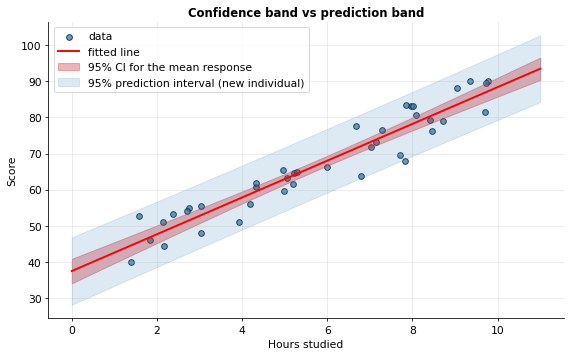

In [17]:
x0 = np.linspace(0, 11, 200)
fit0 = beta[0] + beta[1] * x0
lever = 1 / n + (x0 - x.mean())**2 / Sxx
ci_half = t_crit * np.sqrt(s2 * lever)
pi_half = t_crit * np.sqrt(s2 * (1 + lever))

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(x, y, s=35, edgecolor="k", alpha=.7, label="data")
ax.plot(x0, fit0, "r", lw=2, label="fitted line")
ax.fill_between(x0, fit0 - ci_half, fit0 + ci_half, color="tab:red", alpha=.35, label="95% CI for the mean response")
ax.fill_between(x0, fit0 - pi_half, fit0 + pi_half, color="tab:blue", alpha=.15, label="95% prediction interval (new individual)")
ax.set(xlabel="Hours studied", ylabel="Score", title="Confidence band vs prediction band"); ax.legend(loc="upper left")
inside = np.mean(np.abs(y - (beta[0] + beta[1] * x)) <= t_crit * np.sqrt(s2 * (1 + 1 / n + (x - x.mean())**2 / Sxx)))
print(f"Share of observed points inside the 95% prediction band: {inside:.0%}  (expect ≈ 95%)")
plt.show()

## 5. Special Topics of *Simple* Linear Regression

Because there is only **one** predictor, several beautiful identities connect regression, correlation and variance. They are worth knowing.

### 5.1 Correlation ↔ slope ↔ $R^2$
With $S_{xx}=\sum(x_i-\bar x)^2,\ S_{yy}=\sum(y_i-\bar y)^2,\ S_{xy}=\sum(x_i-\bar x)(y_i-\bar y)$:

$$
r=\frac{S_{xy}}{\sqrt{S_{xx}S_{yy}}},\qquad
\hat\beta_1=\frac{S_{xy}}{S_{xx}}=r\,\frac{s_y}{s_x},\qquad
\boxed{R^2=r^2}
$$

* In **simple** regression, $R^2$ is *literally the squared correlation*.
* If both variables are **standardised** ($z_x,z_y$), the fitted line is $\hat z_y=r\,z_x$: *a 1-SD increase in $x$ predicts an $r$-SD increase in $y$* — never more than 1 SD unless $|r|=1$ (this is *regression to the mean*, 5.3).
* The t-test for the slope is *identical* to the t-test for correlation: $\displaystyle t=\frac{\hat\beta_1}{\text{SE}(\hat\beta_1)}=\frac{r\sqrt{n-2}}{\sqrt{1-r^2}}$.

r = 0.9524   r² = 0.9070   R² from regression = 0.9070
t from correlation formula = 19.2546   |   t = slope/SE = 19.2546
slope of standardised regression = 0.9524 (= r)


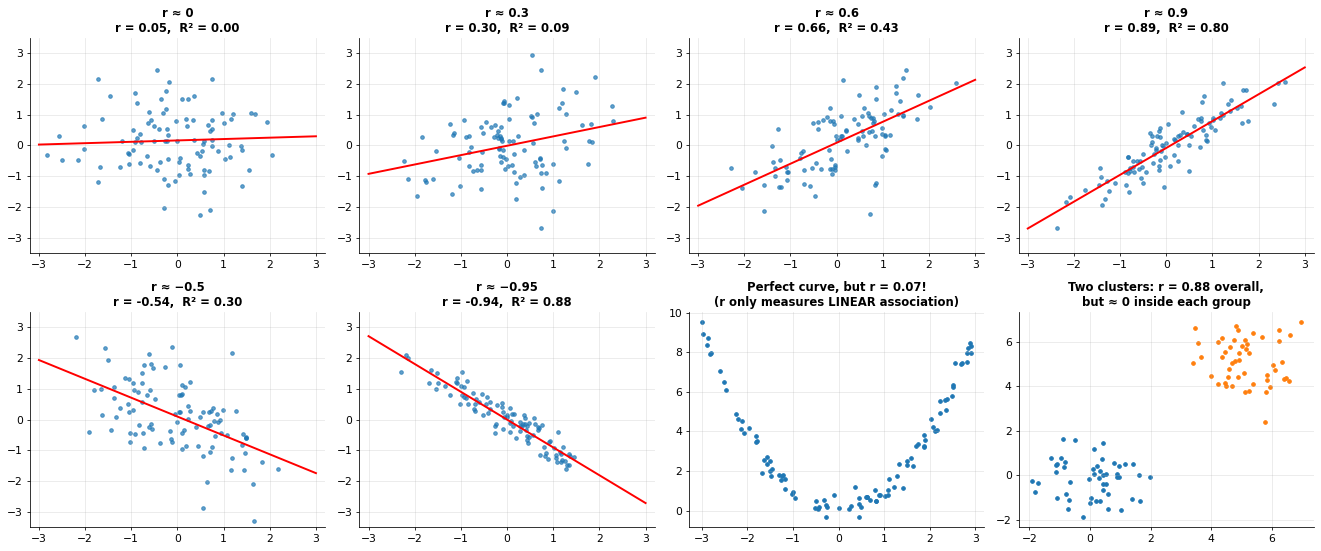

In [18]:
xs_ = df_study["hours"].values; ys_ = df_study["score"].values
r_ = np.corrcoef(xs_, ys_)[0, 1]
fit_ = np.polyfit(xs_, ys_, 1)
e_ = ys_ - np.polyval(fit_, xs_)
R2_ = 1 - (e_ @ e_) / ((ys_ - ys_.mean())**2).sum()
n_ = len(xs_)
t_from_r = r_ * np.sqrt(n_ - 2) / np.sqrt(1 - r_**2)
se1_ = np.sqrt((e_ @ e_ / (n_ - 2)) / ((xs_ - xs_.mean())**2).sum())
print(f"r = {r_:.4f}   r² = {r_**2:.4f}   R² from regression = {R2_:.4f}")
print(f"t from correlation formula = {t_from_r:.4f}   |   t = slope/SE = {fit_[0] / se1_:.4f}")
print(f"slope of standardised regression = {np.polyfit((xs_ - xs_.mean()) / xs_.std(), (ys_ - ys_.mean()) / ys_.std(), 1)[0]:.4f} (= r)")

# What different correlations look like
rng = np.random.default_rng(3)
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
specs = [("r ≈ 0", 0.0), ("r ≈ 0.3", 0.3), ("r ≈ 0.6", 0.6), ("r ≈ 0.9", 0.9), ("r ≈ −0.5", -0.5), ("r ≈ −0.95", -0.95)]
for ax, (lab, rho) in zip(axes.ravel()[:6], specs):
    z = rng.normal(size=100); w = rho * z + np.sqrt(1 - rho**2) * rng.normal(size=100)
    b1_, b0_ = np.polyfit(z, w, 1); rr = np.corrcoef(z, w)[0, 1]
    ax.scatter(z, w, s=14, alpha=.7); g = np.linspace(-3, 3, 10); ax.plot(g, b0_ + b1_ * g, "r", lw=2)
    ax.set(title=f"{lab}\nr = {rr:.2f},  R² = {rr**2:.2f}", xlim=(-3.2, 3.2), ylim=(-3.5, 3.5))
# two situations where r is misleading
xx = rng.uniform(-3, 3, 100); yy = xx**2 + rng.normal(0, .4, 100)
axes[1, 2].scatter(xx, yy, s=14); axes[1, 2].set_title(f"Perfect curve, but r = {np.corrcoef(xx, yy)[0, 1]:.2f}!\n(r only measures LINEAR association)")
c1 = rng.normal(size=(50, 2)); c2 = rng.normal(size=(50, 2)) + 5
allp = np.r_[c1, c2]; axes[1, 3].scatter(*c1.T, s=14); axes[1, 3].scatter(*c2.T, s=14)
axes[1, 3].set_title(f"Two clusters: r = {np.corrcoef(allp.T)[0, 1]:.2f} overall,\nbut ≈ 0 inside each group")
plt.tight_layout(); plt.show()

### 5.2 Anscombe's quartet — *always plot your data*
Four datasets with (almost) **identical** mean, variance, correlation, regression line, $R^2$ and t-statistic… yet completely different stories. Summary numbers can't tell them apart; a plot can instantly.

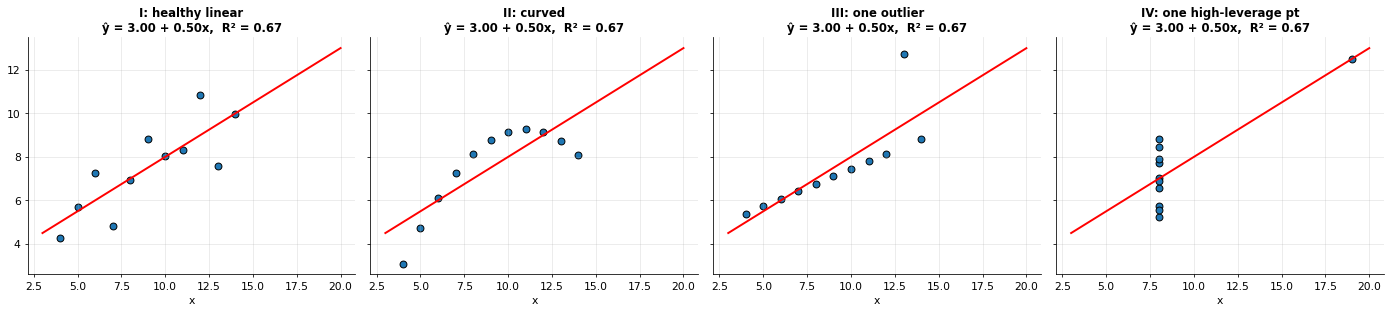

,mean x,mean y,var x,var y,r,slope,intercept
dataset,,,,,,,
I: healthy linear,9.0000,7.5009,11.0000,4.1273,0.8164,0.5001,3.0001
II: curved,9.0000,7.5009,11.0000,4.1276,0.8162,0.5000,3.0009
III: one outlier,9.0000,7.5000,11.0000,4.1226,0.8163,0.4997,3.0025
IV: one high-leverage pt,9.0000,7.5009,11.0000,4.1232,0.8165,0.4999,3.0017


In [19]:
xa = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], float)
ans = {
    "I: healthy linear":         (xa, np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    "II: curved":                (xa, np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])),
    "III: one outlier":          (xa, np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])),
    "IV: one high-leverage pt":  (np.array([8] * 7 + [19] + [8] * 3, float), np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
}
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6), sharey=True); rows = []
for ax, (name, (xq, yq)) in zip(axes, ans.items()):
    b1q, b0q = np.polyfit(xq, yq, 1); rq = np.corrcoef(xq, yq)[0, 1]
    ax.scatter(xq, yq, s=50, edgecolor="k"); g = np.linspace(3, 20, 10); ax.plot(g, b0q + b1q * g, "r", lw=2)
    ax.set_title(f"{name}\nŷ = {b0q:.2f} + {b1q:.2f}x,  R² = {rq**2:.2f}"); ax.set_xlabel("x")
    rows.append({"dataset": name, "mean x": xq.mean(), "mean y": yq.mean(), "var x": xq.var(ddof=1), "var y": yq.var(ddof=1), "r": rq, "slope": b1q, "intercept": b0q})
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index("dataset"))

### 5.3 Regression to the mean (Galton's discovery)
If $x$ and $y$ are imperfectly correlated ($|r|<1$), then extreme $x$ values are on average followed by *less extreme* $y$ values: $\ \mathbb E[z_y|z_x]=r\,z_x$.

*Example:* the students with the top 10 % marks in test 1 will, on average, score lower in test 2 — not because they got lazy, but because part of test-1 success was luck, and luck doesn't repeat. This is a **statistical artefact**, not a causal effect (it explains the "sports-illustrated jinx", "punishment works better than praise" myths, etc.).

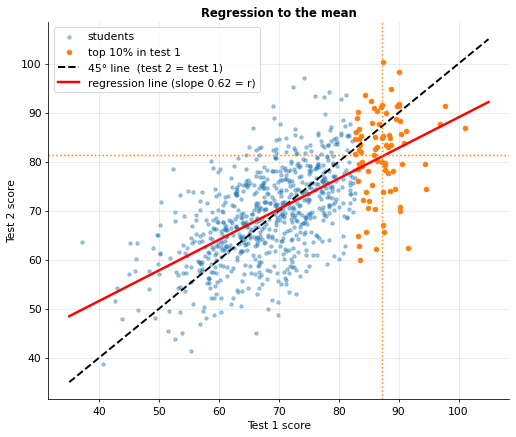

Top-10% group: mean test 1 = 87.2  →  mean test 2 = 81.3   (population mean is 70)


In [20]:
rng = np.random.default_rng(5); nn = 800; rho = 0.6
z1 = rng.normal(size=nn); z2 = rho * z1 + np.sqrt(1 - rho**2) * rng.normal(size=nn)
test1, test2 = 70 + 10 * z1, 70 + 10 * z2
b1_, b0_ = np.polyfit(test1, test2, 1)
top = test1 >= np.quantile(test1, .9)

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(test1[~top], test2[~top], s=12, alpha=.4, label="students"); ax.scatter(test1[top], test2[top], s=22, color="tab:orange", label="top 10% in test 1")
g = np.linspace(35, 105, 10)
ax.plot(g, g, "k--", lw=2, label="45° line  (test 2 = test 1)"); ax.plot(g, b0_ + b1_ * g, "r", lw=2.5, label=f"regression line (slope {b1_:.2f} = r)")
ax.axhline(test2[top].mean(), color="tab:orange", ls=":"); ax.axvline(test1[top].mean(), color="tab:orange", ls=":")
ax.set(xlabel="Test 1 score", ylabel="Test 2 score", title="Regression to the mean"); ax.legend(loc="upper left"); plt.show()
print(f"Top-10% group: mean test 1 = {test1[top].mean():.1f}  →  mean test 2 = {test2[top].mean():.1f}   (population mean is 70)")

### 5.4 Two different regressions: $y$ on $x$ ≠ $x$ on $y$
Regressing $y$ on $x$ minimises **vertical** squared distances; regressing $x$ on $y$ minimises **horizontal** ones. The slopes are

$$b_{y|x}=r\frac{s_y}{s_x},\qquad b_{x|y}=r\frac{s_x}{s_y}\quad\Rightarrow\quad b_{y|x}\cdot b_{x|y}=r^2$$

so the two lines are *not* the same unless $|r|=1$, and one line is **not** the algebraic inverse of the other. Use the regression whose direction matches your prediction task. If both variables are noisy and you want the "symmetric" relationship, use **total least squares / PCA line** (minimises *perpendicular* distances).

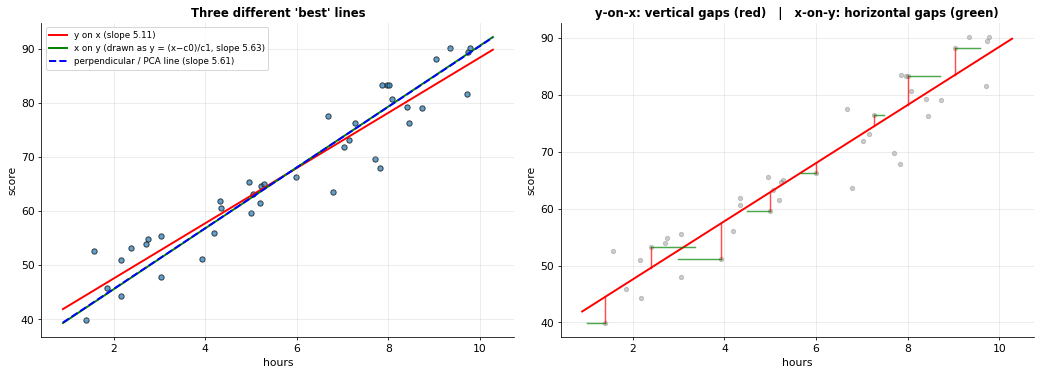

b_y|x = 5.1083,  b_x|y = 0.1776,  product = 0.9070 = r² = 0.9070


In [21]:
x, y = df_study["hours"].values, df_study["score"].values
b_yx = np.polyfit(x, y, 1)                       # y on x
b_xy = np.polyfit(y, x, 1)                       # x on y   (x = c0 + c1*y)
cov = np.cov(x, y); w_, v_ = np.linalg.eigh(cov); pc = v_[:, -1]                          # first principal axis
g = np.linspace(x.min() - .5, x.max() + .5, 100)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ax[0].scatter(x, y, s=30, edgecolor="k", alpha=.7)
ax[0].plot(g, np.polyval(b_yx, g), "r", lw=2, label=f"y on x (slope {b_yx[0]:.2f})")
ax[0].plot(g, (g - b_xy[1]) / b_xy[0], "g", lw=2, label=f"x on y (drawn as y = (x−c0)/c1, slope {1 / b_xy[0]:.2f})")
ax[0].plot(g, y.mean() + pc[1] / pc[0] * (g - x.mean()), "b--", lw=2, label=f"perpendicular / PCA line (slope {pc[1] / pc[0]:.2f})")
ax[0].set(xlabel="hours", ylabel="score", title="Three different 'best' lines"); ax[0].legend(fontsize=9)

# Which distances are minimised?
sub = np.argsort(x)[::5]; a, b = b_yx[0], b_yx[1]
ax[1].scatter(x, y, s=20, alpha=.4, color="grey"); ax[1].plot(g, a * g + b, "r", lw=2)
for i in sub:
    ax[1].plot([x[i], x[i]], [y[i], a * x[i] + b], "r", alpha=.7)                              # vertical (y on x)
    ax[1].plot([x[i], np.polyval(b_xy, y[i])], [y[i], y[i]], "g", alpha=.7)                    # horizontal (x on y)
ax[1].set(xlabel="hours", ylabel="score", title="y-on-x: vertical gaps (red)   |   x-on-y: horizontal gaps (green)")
plt.tight_layout(); plt.show()
r_ = np.corrcoef(x, y)[0, 1]
print(f"b_y|x = {b_yx[0]:.4f},  b_x|y = {b_xy[0]:.4f},  product = {b_yx[0] * b_xy[0]:.4f} = r² = {r_**2:.4f}")

### 5.5 Measurement error in $x$ → the slope is attenuated ("regression dilution")
OLS assumes $x$ is measured **without error**. If we observe $x^*=x+u$ (noise $u$ with variance $\sigma_u^2$), the estimated slope shrinks toward zero:

$$\hat\beta_1\;\xrightarrow{\;p\;}\;\beta_1\cdot\underbrace{\frac{\sigma_x^2}{\sigma_x^2+\sigma_u^2}}_{\text{reliability ratio}\ <\ 1}$$

Noise in $y$ merely widens the scatter; noise in $x$ **biases** the slope. (E.g. self-reported diet or a cheap sensor as predictor.)

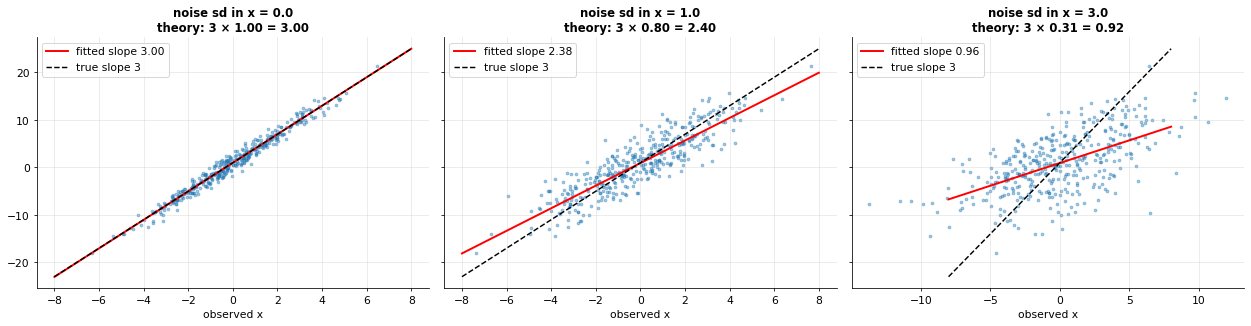

In [22]:
rng = np.random.default_rng(8); n = 5000
x_true = rng.normal(0, 2, n); y_true = 1 + 3 * x_true + rng.normal(0, 1, n)
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
for a_, su in zip(ax, [0.0, 1.0, 3.0]):
    x_obs = x_true + rng.normal(0, su, n) if su > 0 else x_true
    b1_, b0_ = np.polyfit(x_obs, y_true, 1); reli = 4 / (4 + su**2)
    a_.scatter(x_obs[:400], y_true[:400], s=8, alpha=.4); g = np.linspace(-8, 8, 10)
    a_.plot(g, b0_ + b1_ * g, "r", lw=2, label=f"fitted slope {b1_:.2f}"); a_.plot(g, 1 + 3 * g, "k--", label="true slope 3")
    a_.set(title=f"noise sd in x = {su}\ntheory: 3 × {reli:.2f} = {3 * reli:.2f}", xlabel="observed x"); a_.legend()
plt.tight_layout(); plt.show()

### 5.6 Regression through the origin (no intercept)
Sometimes theory says $y=0$ when $x=0$ (e.g. distance = speed × time). The model $y=\beta_1x$ gives $\hat\beta_1=\sum x_iy_i/\sum x_i^2$. **Warnings:**
* Residuals no longer sum to zero and the line need not pass through $(\bar x,\bar y)$.
* $R^2$ is redefined as $1-\text{SSE}/\sum y_i^2$ (uncentred) and is **not comparable** to the usual $R^2$ — it is usually much larger, which is misleading.
* If the true intercept isn't 0, the slope is biased. Force it only with solid scientific justification.

With intercept   : ŷ = 37.35 + 5.11x    R² = 0.907   SSE = 707
Through origin   : ŷ = 10.49x             'R²' (uncentred) = 0.947  ← looks better but isn't;  centred R² = -0.297;  SSE = 9,862


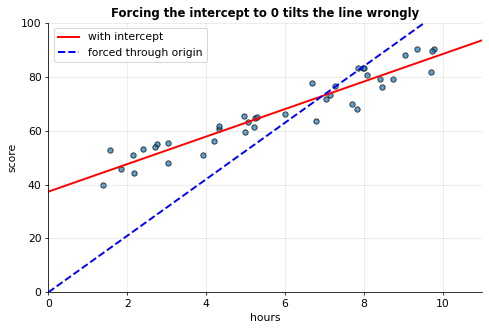

In [23]:
x, y = df_study["hours"].values, df_study["score"].values
b1_o = (x @ y) / (x @ x); e_o = y - b1_o * x
b1_w, b0_w = np.polyfit(x, y, 1); e_w = y - (b0_w + b1_w * x)
R2_o_uncentred = 1 - (e_o @ e_o) / (y @ y); R2_o_centred = 1 - (e_o @ e_o) / ((y - y.mean())**2).sum()
R2_w = 1 - (e_w @ e_w) / ((y - y.mean())**2).sum()
print(f"With intercept   : ŷ = {b0_w:.2f} + {b1_w:.2f}x    R² = {R2_w:.3f}   SSE = {e_w @ e_w:,.0f}")
print(f"Through origin   : ŷ = {b1_o:.2f}x             'R²' (uncentred) = {R2_o_uncentred:.3f}  ← looks better but isn't;  centred R² = {R2_o_centred:.3f};  SSE = {e_o @ e_o:,.0f}")
g = np.linspace(0, 11, 50)
fig, ax = plt.subplots(figsize=(8, 5)); ax.scatter(x, y, s=30, edgecolor="k", alpha=.7)
ax.plot(g, b0_w + b1_w * g, "r", lw=2, label="with intercept"); ax.plot(g, b1_o * g, "b--", lw=2, label="forced through origin"); ax.set(xlim=(0, 11), ylim=(0, 100), xlabel="hours", ylabel="score", title="Forcing the intercept to 0 tilts the line wrongly"); ax.legend(); plt.show()

### 5.7 What makes the slope *precise*?
$$\text{SE}(\hat\beta_1)=\frac{\sigma}{\sqrt{S_{xx}}}=\frac{\sigma}{\sqrt{(n-1)}\,s_x}$$

Three levers: **less noise ($\sigma$↓)**, **more data ($n$↑)**, and — often forgotten — **more spread in $x$ ($s_x$↑)**. A tiny range of $x$ gives a very uncertain slope even with many points. Design your experiments to *spread out* $x$ (in the range where the model is valid).

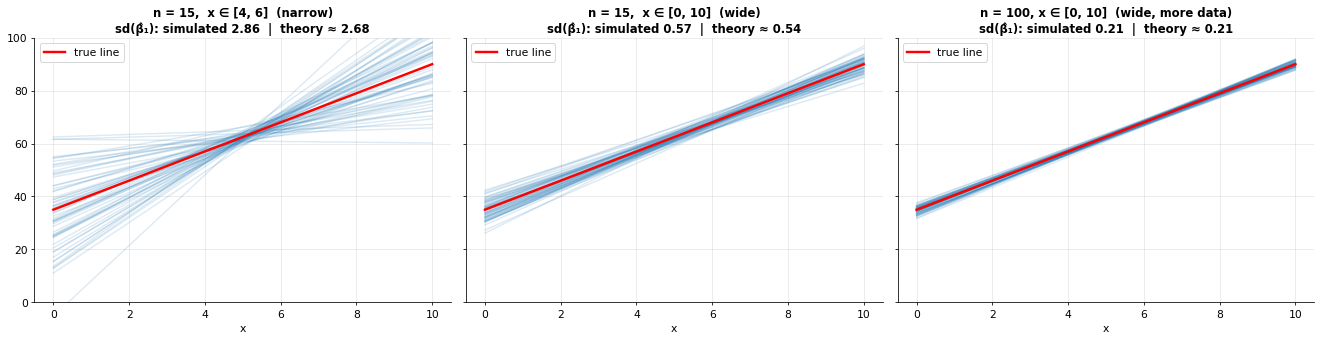

In [24]:
def simulate_lines(n, xlo, xhi, sigma=6, reps=200, seed=0):
    rng = np.random.default_rng(seed); out = []
    for _ in range(reps):
        xx = rng.uniform(xlo, xhi, n); yy = 35 + 5.5 * xx + rng.normal(0, sigma, n)
        out.append(np.polyfit(xx, yy, 1))
    return np.array(out)

designs = [("n = 15,  x ∈ [4, 6]  (narrow)", 15, 4, 6), ("n = 15,  x ∈ [0, 10]  (wide)", 15, 0, 10), ("n = 100, x ∈ [0, 10]  (wide, more data)", 100, 0, 10)]
g = np.linspace(0, 10, 10)
fig, ax = plt.subplots(1, 3, figsize=(19, 5), sharey=True)
for a_, (lab, n, lo, hi) in zip(ax, designs):
    co = simulate_lines(n, lo, hi)
    for b1_, b0_ in co[:60]: a_.plot(g, b0_ + b1_ * g, color="tab:blue", alpha=.15)
    a_.plot(g, 35 + 5.5 * g, "r", lw=2.5, label="true line")
    theory = 6 / np.sqrt(n * (hi - lo)**2 / 12)
    a_.set(title=f"{lab}\nsd(β̂₁): simulated {co[:, 0].std():.2f}  |  theory ≈ {theory:.2f}", xlabel="x", ylim=(0, 100)); a_.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 6. Assumptions & Diagnostics — *Can we trust the numbers?*

The classical simple-regression model is

$$y_i=\beta_0+\beta_1x_i+\varepsilon_i,\qquad \varepsilon_i\ \overset{iid}{\sim}\ \mathcal N(0,\sigma^2)$$

which packs four assumptions (remember **L-I-N-E**), plus "x is measured without error / fixed":

| | Assumption | If violated | How to check | Typical fix |
|---|---|---|---|---|
| **L** | **Linearity** – $E[y|x]=\beta_0+\beta_1x$ | biased predictions | Residuals vs fitted/$x$ (should be a flat, patternless cloud) | transform $x$/$y$, add $x^2$ |
| **I** | **Independence** of errors | SEs too small, false significance | Durbin–Watson, residuals vs time/order | time-series models, clustered SEs |
| **N** | **Normality** of errors *(only needed for exact small-sample t/F/intervals)* | inference inaccurate for small $n$ | Q–Q plot, Shapiro–Wilk | transform $y$, more data (CLT helps) |
| **E** | **Equal variance** (homoscedasticity) | SEs/intervals wrong (coefficients still unbiased) | Residuals vs fitted (funnel?), Breusch–Pagan | log-transform, **WLS**, robust (HC) SEs |

With one predictor, "residuals vs fitted" and "residuals vs $x$" are the same picture (fitted values are just a rescaled $x$). Below: three datasets — one healthy, one with curvature, one with a funnel-shaped variance — and the four standard diagnostic plots for each.

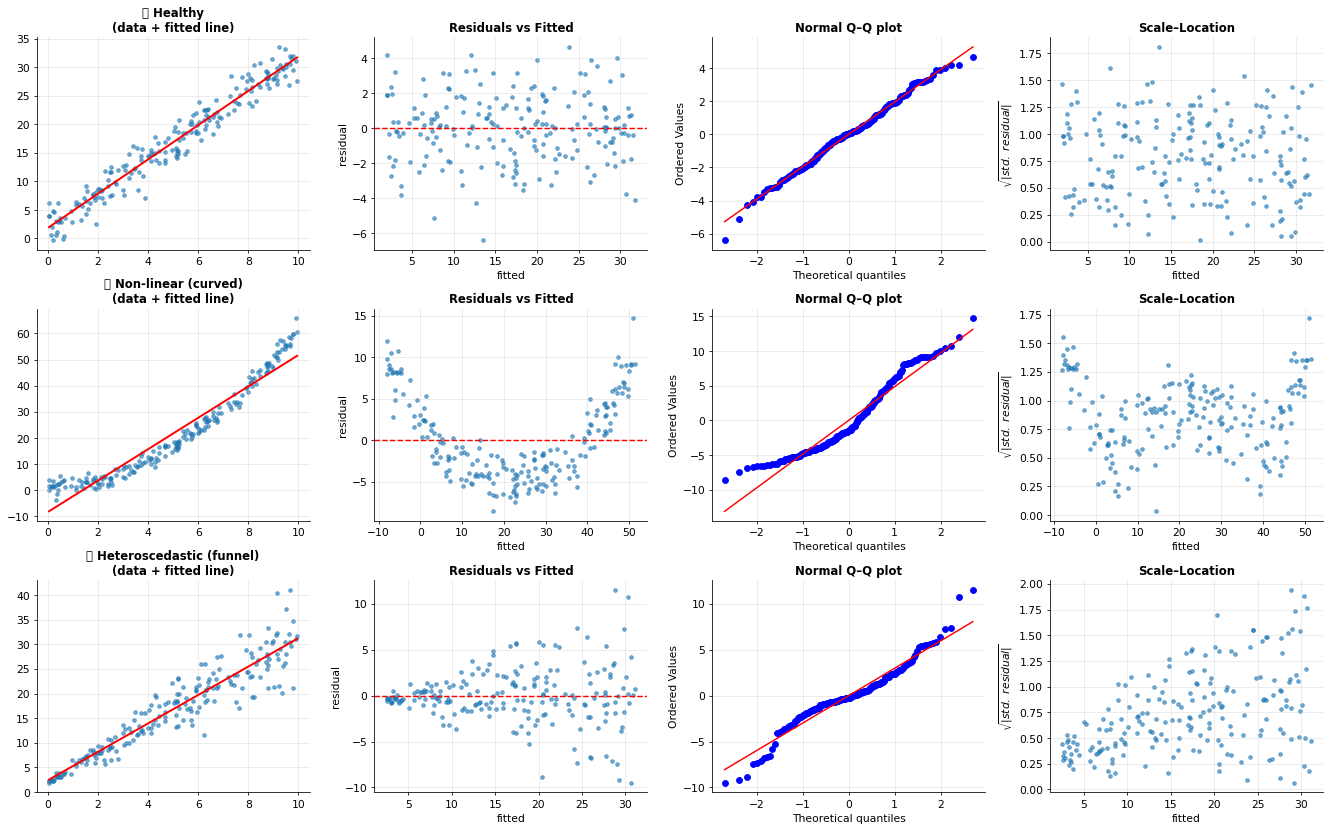

In [25]:
def diag_row(axs, x, y, title):
    Xd = np.c_[np.ones(len(x)), x]
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]; fit = Xd @ b; e = y - fit
    o = np.argsort(x)
    axs[0].scatter(x, y, s=14, alpha=.6); axs[0].plot(x[o], fit[o], "r", lw=2); axs[0].set_title(f"{title}\n(data + fitted line)")
    axs[1].scatter(fit, e, s=14, alpha=.6); axs[1].axhline(0, color="r", ls="--")
    axs[1].set(title="Residuals vs Fitted", xlabel="fitted", ylabel="residual")
    stats.probplot(e, dist="norm", plot=axs[2]); axs[2].set_title("Normal Q–Q plot")
    std = e / e.std(ddof=2)
    axs[3].scatter(fit, np.sqrt(np.abs(std)), s=14, alpha=.6); axs[3].set(title="Scale–Location", xlabel="fitted", ylabel=r"$\sqrt{|std.\ residual|}$")

rng = np.random.default_rng(7); m = 200
xg = rng.uniform(0, 10, m)
datasets = {
    "✅ Healthy": 2 + 3 * xg + rng.normal(0, 2, m),
    "❌ Non-linear (curved)": 2 + 0.6 * xg**2 + rng.normal(0, 2, m),
    "❌ Heteroscedastic (funnel)": 2 + 3 * xg + rng.normal(0, 1, m) * (0.2 + 0.5 * xg),
}
fig, axes = plt.subplots(3, 4, figsize=(19, 12))
for row, (name, yy) in zip(axes, datasets.items()):
    diag_row(row, xg, yy, name)
plt.tight_layout(); plt.show()

**How to read them**
* **Residuals vs Fitted** – want a random horizontal band. A **U-shape ⇒ non-linearity**; a **funnel ⇒ heteroscedasticity**.
* **Q–Q plot** – residual quantiles vs Normal quantiles; points on the diagonal ⇒ normal. S-curves/heavy tails ⇒ non-normal.
* **Scale–Location** – a rising trend ⇒ variance grows with the fitted value.

### 6.1 Formal tests (implemented by hand so you see the mechanics)
* **Shapiro–Wilk** ($H_0$: residuals are Normal).
* **Breusch–Pagan** ($H_0$: constant variance): regress $e_i^2$ on the predictors; $LM=n\cdot R^2_{aux}\sim\chi^2_p$.
* **Durbin–Watson** (autocorrelation): $DW=\dfrac{\sum_t(e_t-e_{t-1})^2}{\sum_t e_t^2}\approx2(1-\hat\rho)$. About 2 ⇒ no autocorrelation; near 0 ⇒ positive; near 4 ⇒ negative.

(In Section 7 we call the ready-made statsmodels versions.)

In [26]:
def tests(x, y):
    Xd = np.c_[np.ones(len(x)), x]
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]; e = y - Xd @ b
    sh_p = stats.shapiro(e).pvalue
    b_aux = np.linalg.lstsq(Xd, e**2, rcond=None)[0]; e2 = e**2
    r2_aux = 1 - ((e2 - Xd @ b_aux)**2).sum() / ((e2 - e2.mean())**2).sum()
    bp_p = stats.chi2.sf(len(x) * r2_aux, df=1)
    o = np.argsort(x); eo = e[o]
    dw = np.sum(np.diff(eo)**2) / np.sum(eo**2)
    return {"Shapiro p (normality)": sh_p, "Breusch-Pagan p (const. var.)": bp_p, "Durbin-Watson": dw}

out = pd.DataFrame({name: tests(xg, yy) for name, yy in datasets.items()}).T
display(out)
print("Reject H0 when p < 0.05.  Notice: the funnel dataset fails Breusch–Pagan; the curved one fails Durbin–Watson (patterned residuals when sorted by x) and typically Shapiro.")

Reject H0 when p < 0.05.  Notice: the funnel dataset fails Breusch–Pagan; the curved one fails Durbin–Watson (patterned residuals when sorted by x) and typically Shapiro.


,Shapiro p (normality),Breusch-Pagan p (const. var.),Durbin-Watson
✅ Healthy,0.5614,0.5749,2.0105
❌ Non-linear (curved),0.0000,0.7337,0.2466
❌ Heteroscedastic (funnel),0.0000,0.0000,2.1726


### 6.2 Outliers, leverage & influence
Not every unusual point matters equally:
* **Outlier** – large residual (unusual $y$ given $x$).
* **High leverage** – unusual $x$; measured by the diagonal of the hat matrix, $h_{ii}=\mathbf x_i^\top(\mathbf X^\top\mathbf X)^{-1}\mathbf x_i$ (average $=(p+1)/n$; flag $>2(p+1)/n$).
* **Influential** – removing the point *changes the fit substantially*: usually high leverage **and** large residual. **Cook's distance**
$$D_i=\frac{e_i^2}{(p+1)s^2}\cdot\frac{h_{ii}}{(1-h_{ii})^2}\qquad(\text{flag }D_i>4/n)$$
* **Studentised residual:** $r_i=\dfrac{e_i}{s\sqrt{1-h_{ii}}}$ (|r| > 3 is suspicious).

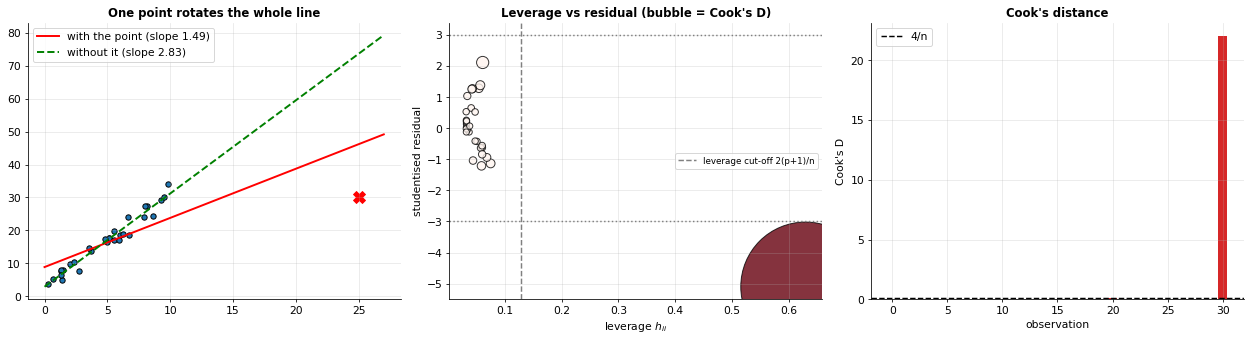

Flagged by Cook's D > 4/n: observations [20, 30]


In [27]:
rng = np.random.default_rng(11)
xi = rng.uniform(0, 10, 30); yi = 2 + 3 * xi + rng.normal(0, 2, 30)
xi = np.append(xi, 25); yi = np.append(yi, 30)                    # a far-away x with an off-trend y  → influential!

Xi = np.c_[np.ones(len(xi)), xi]; pp = 1
bi = np.linalg.lstsq(Xi, yi, rcond=None)[0]; ei = yi - Xi @ bi
h = np.diag(Xi @ np.linalg.inv(Xi.T @ Xi) @ Xi.T)
s2i = ei @ ei / (len(xi) - pp - 1)
stud = ei / np.sqrt(s2i * (1 - h))
cook = ei**2 / ((pp + 1) * s2i) * h / (1 - h)**2

b_clean = np.polyfit(xi[:-1], yi[:-1], 1)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
gg = np.linspace(0, 27, 50)
ax[0].scatter(xi, yi, s=30, edgecolor="k"); ax[0].scatter(xi[-1], yi[-1], s=150, color="red", marker="X")
ax[0].plot(gg, bi[0] + bi[1] * gg, "r", lw=2, label=f"with the point (slope {bi[1]:.2f})")
ax[0].plot(gg, b_clean[1] + b_clean[0] * gg, "g--", lw=2, label=f"without it (slope {b_clean[0]:.2f})"); ax[0].legend(); ax[0].set_title("One point rotates the whole line")
sc = ax[1].scatter(h, stud, s=40 + 800 * cook, c=cook, cmap="Reds", edgecolor="k", alpha=.8)
ax[1].axvline(2 * (pp + 1) / len(xi), color="grey", ls="--", label="leverage cut-off 2(p+1)/n"); ax[1].axhline(3, color="grey", ls=":"); ax[1].axhline(-3, color="grey", ls=":")
ax[1].set(xlabel="leverage $h_{ii}$", ylabel="studentised residual", title="Leverage vs residual (bubble = Cook's D)"); ax[1].legend(fontsize=9)
ax[2].bar(range(len(cook)), cook, color=np.where(cook > 4 / len(xi), "tab:red", "tab:blue")); ax[2].axhline(4 / len(xi), color="k", ls="--", label="4/n")
ax[2].set(xlabel="observation", ylabel="Cook's D", title="Cook's distance"); ax[2].legend()
plt.tight_layout(); plt.show()
print(f"Flagged by Cook's D > 4/n: observations {np.where(cook > 4 / len(xi))[0].tolist()}")

**What to do with influential points?** Investigate first (data-entry error? genuinely different population?). Delete only with a *documented* reason. Otherwise use robust regression (Huber) or report results with and without the point.

## 7. Linear Regression with **statsmodels** (the statistician's tool)

`statsmodels` is built for **inference**: it gives coefficient tables, p-values, confidence intervals and diagnostics out-of-the-box.

Two important API facts:
* `sm.OLS(y, X)` **does not add an intercept automatically** → use `sm.add_constant(X)`.
* The formula API `smf.ols("y ~ x1 + x2", data=df)` (R-style) **adds the intercept for you** and handles categoricals with `C(var)`.

### 7.1 Fit and print the summary

In [ ]:
X_sm = sm.add_constant(df_study[["hours"]])          # adds a column of ones named 'const'
ols = sm.OLS(df_study["score"], X_sm).fit()
print(ols.summary())

### 7.2 Reading `summary()` line by line

**Top-left block — model description**
| Field | Meaning |
|---|---|
| Dep. Variable | the target $y$ |
| Model / Method | OLS / Least Squares |
| No. Observations | $n$ |
| Df Residuals | $n-p-1$ (degrees of freedom left after estimating parameters) |
| Df Model | $p$ (number of predictors, intercept excluded) |
| Covariance Type | `nonrobust` = classical $\sigma^2(\mathbf X^\top\mathbf X)^{-1}$ (assumes homoscedasticity). Alternatives: `HC0–HC3` (robust), `cluster`, `HAC` |

**Top-right block — overall fit**
| Field | Meaning |
|---|---|
| R-squared | $1-\text{SSE}/\text{SST}$ — variance explained |
| Adj. R-squared | penalised for the number of predictors |
| F-statistic, Prob (F-statistic) | joint test that *all* slopes are 0; small p ⇒ the model as a whole is useful |
| Log-Likelihood | Gaussian $\ell$ from Section 4 |
| AIC / BIC | $2k-2\ell$ and $k\ln n-2\ell$ — compare *competing models on the same data* (lower = better) |

**Middle block — coefficient table**
| Column | Meaning |
|---|---|
| coef | $\hat\beta_j$ |
| std err | $\text{SE}(\hat\beta_j)$ — precision of the estimate |
| t | $\hat\beta_j/\text{SE}$ |
| P>\|t\| | two-sided p-value for $H_0:\beta_j=0$ |
| [0.025, 0.975] | 95% confidence interval |

**Bottom block — residual diagnostics**
| Field | Meaning |
|---|---|
| Omnibus / Prob(Omnibus) | D'Agostino test of normality of residuals (skewness + kurtosis) |
| Skew | 0 for symmetric residuals |
| Kurtosis | 3 for Normal; >3 heavy tails |
| Durbin-Watson | ≈2 ⇒ no first-order autocorrelation |
| Jarque-Bera (JB) / Prob(JB) | another normality test |
| Cond. No. | condition number of $\mathbf X$; large (>30 by rule of thumb, e.g. unscaled features) hints at multicollinearity/numerical issues |

The footnote **[1] Standard Errors assume that the covariance matrix of the errors is correctly specified** is a reminder that all p-values rely on the assumptions in Section 6.

### 7.3 Programmatic access & agreement with our hand computation

In [ ]:
x = df_study["hours"].values; y = df_study["score"].values     # (re-bind: earlier sections re-used these names)
print("Parameters\n", ols.params, "\n\nStd errors\n", ols.bse, "\n\nt-values\n", ols.tvalues, "\n\np-values\n", ols.pvalues)
print("\n95% CI\n", ols.conf_int(alpha=0.05))
print(f"\nR² = {ols.rsquared:.4f} | adj R² = {ols.rsquared_adj:.4f} | F = {ols.fvalue:.2f} (p={ols.f_pvalue:.2e}) | AIC = {ols.aic:.2f} | BIC = {ols.bic:.2f} | s = {np.sqrt(ols.mse_resid):.4f}")

print("\nMatches Section 4 (by hand)?")
print("  coefficients :", np.allclose(ols.params.values, beta))
print("  std errors   :", np.allclose(ols.bse.values, se))
print("  p-values     :", np.allclose(ols.pvalues.values, p_vals))
print("  AIC / BIC    :", np.isclose(ols.aic, summary_by_hand['AIC']), np.isclose(ols.bic, summary_by_hand['BIC']))

### 7.4 Formula API, robust standard errors, and prediction intervals

In [ ]:
# (a) R-style formula – intercept is automatic
ols_f = smf.ols("score ~ hours", data=df_study).fit()
print("Formula API params:", ols_f.params.round(4).to_dict())

# (b) Heteroscedasticity-robust (White / HC3) standard errors – same coefficients, safer SEs & p-values
ols_rob = smf.ols("score ~ hours", data=df_study).fit(cov_type="HC3")
print("\nClassical SE :", ols_f.bse.round(4).to_dict())
print("Robust HC3 SE:", ols_rob.bse.round(4).to_dict())

# (c) Confidence and prediction intervals for new inputs
new = pd.DataFrame({"hours": [2, 5, 8, 10]})
pred = ols_f.get_prediction(new).summary_frame(alpha=0.05)
pred.insert(0, "hours", new["hours"])
display(pred.rename(columns={"mean": "prediction", "mean_ci_lower": "CI_low", "mean_ci_upper": "CI_high", "obs_ci_lower": "PI_low", "obs_ci_upper": "PI_high"}))

# (d) Plot the bands straight from statsmodels
grid = pd.DataFrame({"hours": np.linspace(0, 11, 100)})
sf = ols_f.get_prediction(grid).summary_frame(alpha=0.05)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, s=30, edgecolor="k", alpha=.7)
ax.plot(grid["hours"], sf["mean"], "r", lw=2)
ax.fill_between(grid["hours"], sf["mean_ci_lower"], sf["mean_ci_upper"], color="tab:red", alpha=.35, label="95% CI (mean)")
ax.fill_between(grid["hours"], sf["obs_ci_lower"], sf["obs_ci_upper"], color="tab:blue", alpha=.15, label="95% PI (individual)")
ax.set(xlabel="Hours", ylabel="Score", title="statsmodels intervals (identical to Section 4.3)"); ax.legend(); plt.show()

### 7.5 Ready-made diagnostics

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera

bp = het_breuschpagan(ols.resid, ols.model.exog)
jb = jarque_bera(ols.resid)
print(f"Breusch–Pagan  LM = {bp[0]:.3f}, p = {bp[1]:.3f}   (H0: constant variance)")
print(f"Jarque–Bera    JB = {jb[0]:.3f}, p = {jb[1]:.3f}   (H0: normal residuals)")
print(f"Durbin–Watson  DW = {durbin_watson(ols.resid):.3f}   (≈2 ⇒ independent)")

infl = ols.get_influence()
d = pd.DataFrame({"leverage": infl.hat_matrix_diag, "student_resid": infl.resid_studentized_external, "cooks_d": infl.cooks_distance[0]})
print("\nTop 3 most influential observations:"); display(d.sort_values("cooks_d", ascending=False).head(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
sm.qqplot(ols.resid, line="s", ax=ax[0]); ax[0].set_title("statsmodels Q–Q plot")
ax[1].scatter(ols.fittedvalues, ols.resid, s=25, alpha=.7); ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="fitted", ylabel="residual", title="Residuals vs fitted"); plt.tight_layout(); plt.show()

## 8. Linear Regression with **scikit-learn** (the machine-learner's tool)

scikit-learn focuses on **prediction & generalisation**: a uniform `fit / predict / score` API, pipelines, train/test splitting, cross-validation and hyper-parameter tuning. It deliberately provides *no* p-values or confidence intervals.

Key points about `LinearRegression`:
* Adds the intercept for you (`fit_intercept=True`); coefficients are in `coef_`, intercept in `intercept_`.
* Solves least squares via SVD (`scipy.linalg.lstsq`) — no gradient descent.
* `X` must be 2-D: shape `(n_samples, n_features)`.
* `.score(X, y)` returns $R^2$.

### 8.1 Fit, predict, evaluate

In [28]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Xs = df_study[["hours"]]; ys = df_study["score"]
lin = LinearRegression().fit(Xs, ys)
print(f"intercept_ = {lin.intercept_:.4f},  coef_ = {lin.coef_[0]:.4f},  R² = {lin.score(Xs, ys):.4f}")
print("Prediction for 6.5 hours:", round(float(lin.predict(pd.DataFrame({'hours': [6.5]}))[0]), 2))

# --- proper evaluation: hold out a test set the model never sees
X_tr, X_te, y_tr, y_te = train_test_split(Xs, ys, test_size=0.25, random_state=0)
m = LinearRegression().fit(X_tr, y_tr)
for name, (Xa, ya) in {"train": (X_tr, y_tr), "test": (X_te, y_te)}.items():
    pr = m.predict(Xa)
    print(f"{name:5s}: R² = {metrics.r2_score(ya, pr):.3f} | RMSE = {np.sqrt(metrics.mean_squared_error(ya, pr)):.3f} | MAE = {metrics.mean_absolute_error(ya, pr):.3f}")

intercept_ = 37.3518,  coef_ = 5.1083,  R² = 0.9070
Prediction for 6.5 hours: 70.56
train: R² = 0.902 | RMSE = 4.140 | MAE = 3.540
test : R² = 0.917 | RMSE = 4.411 | MAE = 3.606


### 8.2 Cross-validation
A single split is noisy (lucky/unlucky test set). **$K$-fold CV** splits the data in $K$ parts, trains on $K-1$, tests on the remaining one, and rotates:
$$\text{CV-RMSE}=\frac1K\sum_{k=1}^K \text{RMSE}_k$$
This gives an honest estimate of **out-of-sample** error *and* its variability.

RMSE per fold: [4.65 4.13 3.56 4.96 5.03] → mean 4.46 ± 0.55
R²   per fold: [0.919 0.886 0.938 0.797 0.827] → mean 0.873


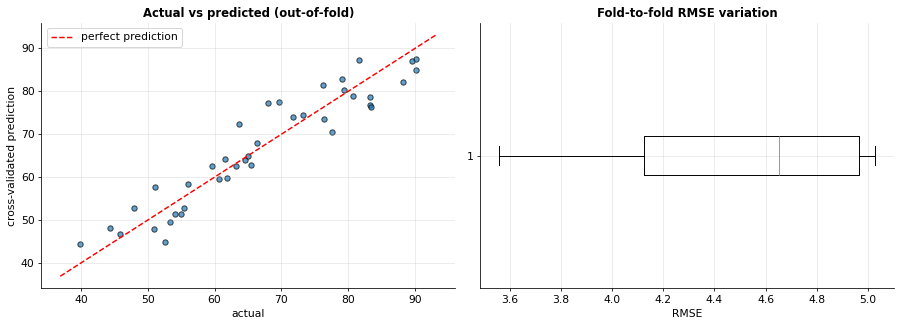

In [29]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rmse_cv = -cross_val_score(LinearRegression(), Xs, ys, cv=kf, scoring="neg_root_mean_squared_error")
r2_cv = cross_val_score(LinearRegression(), Xs, ys, cv=kf, scoring="r2")
print("RMSE per fold:", rmse_cv.round(2), f"→ mean {rmse_cv.mean():.2f} ± {rmse_cv.std():.2f}")
print("R²   per fold:", r2_cv.round(3), f"→ mean {r2_cv.mean():.3f}")

pred_cv = cross_val_predict(LinearRegression(), Xs, ys, cv=kf)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].scatter(ys, pred_cv, s=30, edgecolor="k", alpha=.7); lim = [ys.min() - 3, ys.max() + 3]
ax[0].plot(lim, lim, "r--", label="perfect prediction"); ax[0].set(xlabel="actual", ylabel="cross-validated prediction", title="Actual vs predicted (out-of-fold)"); ax[0].legend()
ax[1].boxplot(rmse_cv, vert=False); ax[1].set(title="Fold-to-fold RMSE variation", xlabel="RMSE")
plt.tight_layout(); plt.show()

### 8.3 Pipelines & scaling
A `Pipeline` chains preprocessing + model so that **scaling parameters are learned from training data only** (avoiding *data leakage*). For plain OLS, scaling doesn't change predictions, only the meaning of coefficients (per 1 standard deviation instead of per unit) — but it is *essential* for gradient-based solvers and for regularised models (when you later move to many features).

$$\hat y=\beta_0+\beta_1x=\underbrace{(\beta_0+\beta_1\mu)}_{\gamma_0}+\underbrace{(\beta_1\sigma)}_{\gamma_1}\,\frac{x-\mu}{\sigma}$$

In [30]:
pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(Xs, ys)
lr_step, sc_step = pipe[-1], pipe[0]
gamma0, gamma1 = lr_step.intercept_, lr_step.coef_[0]
mu_, sd_ = sc_step.mean_[0], sc_step.scale_[0]
print(f"Scaled model: intercept={gamma0:.3f} (=mean of y {ys.mean():.3f}), slope per 1 SD of hours = {gamma1:.3f}")
print(f"Back to original units: slope = {gamma1 / sd_:.4f}, intercept = {gamma0 - gamma1 * mu_ / sd_:.4f}   (matches LinearRegression)")

# SGDRegressor = gradient-descent version of the same model (Section 3.4/3.5)
sgd_m = make_pipeline(StandardScaler(), SGDRegressor(loss="squared_error", penalty=None, learning_rate="constant", eta0=0.01, max_iter=5000, tol=1e-8, random_state=0)).fit(Xs, ys)
g0, g1 = sgd_m[-1].intercept_[0], sgd_m[-1].coef_[0]
print(f"SGDRegressor in original units: slope = {g1 / sd_:.4f}, intercept = {g0 - g1 * mu_ / sd_:.4f}")

Scaled model: intercept=66.992 (=mean of y 66.992), slope per 1 SD of hours = 13.131
Back to original units: slope = 5.1083, intercept = 37.3518   (matches LinearRegression)
SGDRegressor in original units: slope = 5.1014, intercept = 37.3253


### 8.4 All roads lead to the same line

In [31]:
comp = pd.DataFrame({
    "closed form (Sec 3.1)":  [b0, b1],
    "normal equation":        beta_solve,
    "np.linalg.lstsq":        beta_lstsq,
    "gradient descent (3.4)": [b0_gd, b1_gd],
    "statsmodels OLS":        ols.params.values,
    "sklearn LinearRegression": [lin.intercept_, lin.coef_[0]],
    "sklearn SGDRegressor":   [g0 - g1 * mu_ / sd_, g1 / sd_],
}, index=["intercept β0", "slope β1"]).T
display(comp)
print("True values used to generate the data: β0 = 35, β1 = 5.5")

True values used to generate the data: β0 = 35, β1 = 5.5


,intercept β0,slope β1
closed form (Sec 3.1),37.3518,5.1083
normal equation,37.3518,5.1083
np.linalg.lstsq,37.3518,5.1083
gradient descent (3.4),37.3518,5.1083
statsmodels OLS,37.3518,5.1083
sklearn LinearRegression,37.3518,5.1083
sklearn SGDRegressor,37.3253,5.1014


### 8.5 statsmodels vs scikit-learn — when to use which
| | statsmodels | scikit-learn |
|---|---|---|
| Goal | **Explain** (inference, hypothesis tests) | **Predict** (generalisation) |
| p-values, CIs, AIC/BIC, diagnostics | ✅ built in | ❌ |
| Intercept | manual `add_constant` (or formula) | automatic |
| Train/test, CV, pipelines, tuning | ❌ (manual) | ✅ |
| Regularisation | limited (`fit_regularized`) | ✅ Ridge, Lasso, ElasticNet, … |
| Typical workflow | econometrics, science, A/B analysis | ML products, benchmarking |

In practice, **use both**: scikit-learn to validate predictive performance, statsmodels to understand and defend the coefficients.

## 9. When a Straight Line Isn't Enough — Transformations

"Linear" only requires the model to be linear in **β**. Transforming $y$ and/or $x$ lets the *same* machinery model curves, fix skewness and stabilise variance. The interpretation of $\beta_1$ changes:

| Model | Equation | Interpretation of $\beta_1$ |
|---|---|---|
| level–level | $y=\beta_0+\beta_1x$ | +1 unit of $x$ → **+$\beta_1$ units** of $y$ |
| log–level | $\ln y=\beta_0+\beta_1x$ | +1 unit of $x$ → **≈ 100·$\beta_1$ %** change in $y$ (exactly $100(e^{\beta_1}-1)$ %) |
| level–log | $y=\beta_0+\beta_1\ln x$ | +1 % in $x$ → **≈ $\beta_1/100$ units** of $y$ |
| **log–log** | $\ln y=\beta_0+\beta_1\ln x$ | +1 % in $x$ → **≈ $\beta_1$ %** in $y$ — $\beta_1$ is the **elasticity** |
| quadratic | $y=\beta_0+\beta_1x+\beta_2x^2$ | slope depends on $x$: $\beta_1+2\beta_2x$ (still linear in β) |

**Example:** many "power-law" relationships (metabolic rate vs body mass, demand vs price) are straight lines on log–log axes. Below, the true relation is $y=3x^{0.6}\varepsilon$ with multiplicative noise.

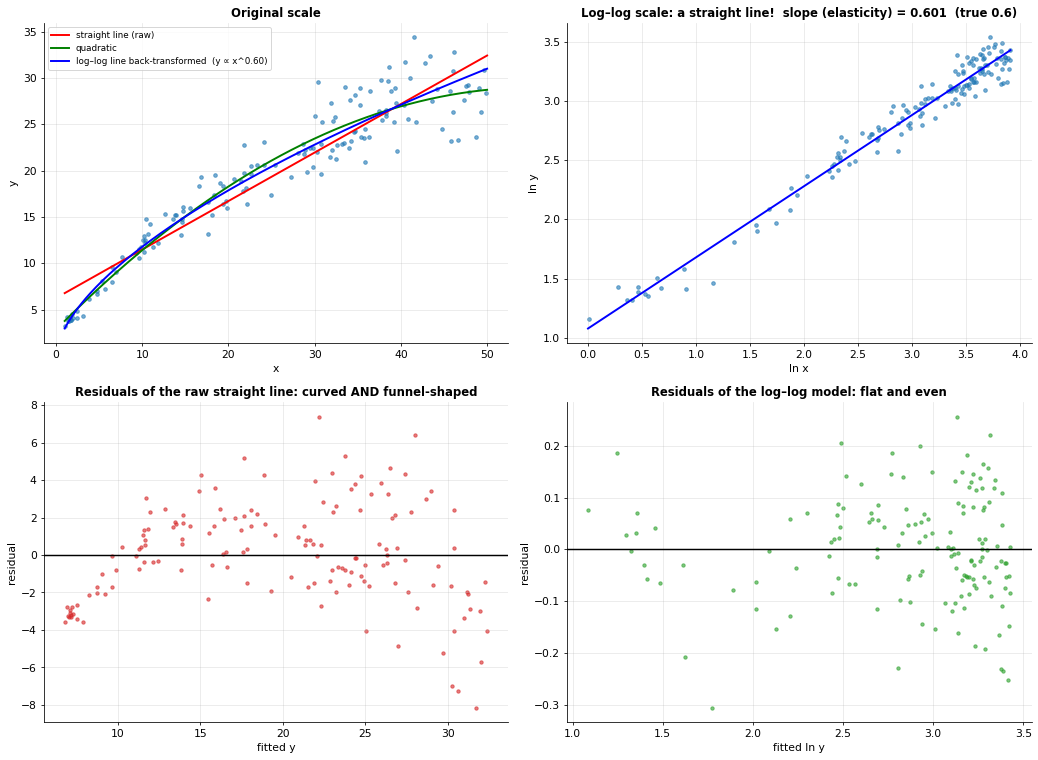

RMSE in original units  →  straight line: 2.685 | quadratic: 2.178 | log–log (with smearing): 2.250
Interpretation: a 1% increase in x is associated with about a 0.60% increase in y  (true elasticity 0.6).


In [32]:
rng = np.random.default_rng(21)
n = 150
xp = rng.uniform(1, 50, n); yp = 3 * xp**0.6 * np.exp(rng.normal(0, 0.12, n))

# (a) straight line on raw data   (b) straight line on log–log data   (c) quadratic on raw data
b1_a, b0_a = np.polyfit(xp, yp, 1)
b1_b, b0_b = np.polyfit(np.log(xp), np.log(yp), 1)
q = np.polyfit(xp, yp, 2)
e_a = yp - (b0_a + b1_a * xp); e_b = np.log(yp) - (b0_b + b1_b * np.log(xp))
smear = np.mean(np.exp(e_b))
pred_b = smear * np.exp(b0_b + b1_b * np.log(xp))

g = np.linspace(1, 50, 200)
fig, ax = plt.subplots(2, 2, figsize=(15, 11))
ax[0, 0].scatter(xp, yp, s=14, alpha=.6)
ax[0, 0].plot(g, b0_a + b1_a * g, "r", lw=2, label="straight line (raw)")
ax[0, 0].plot(g, np.polyval(q, g), "g", lw=2, label="quadratic")
ax[0, 0].plot(g, smear * np.exp(b0_b) * g**b1_b, "b", lw=2, label=f"log–log line back-transformed  (y ∝ x^{b1_b:.2f})")
ax[0, 0].set(title="Original scale", xlabel="x", ylabel="y"); ax[0, 0].legend(fontsize=9)
ax[0, 1].scatter(np.log(xp), np.log(yp), s=14, alpha=.6); gl = np.log(g); ax[0, 1].plot(gl, b0_b + b1_b * gl, "b", lw=2)
ax[0, 1].set(title=f"Log–log scale: a straight line!  slope (elasticity) = {b1_b:.3f}  (true 0.6)", xlabel="ln x", ylabel="ln y")
ax[1, 0].scatter(b0_a + b1_a * xp, e_a, s=12, alpha=.6, color="tab:red"); ax[1, 0].axhline(0, color="k")
ax[1, 0].set(title="Residuals of the raw straight line: curved AND funnel-shaped", xlabel="fitted y", ylabel="residual")
ax[1, 1].scatter(b0_b + b1_b * np.log(xp), e_b, s=12, alpha=.6, color="tab:green"); ax[1, 1].axhline(0, color="k")
ax[1, 1].set(title="Residuals of the log–log model: flat and even", xlabel="fitted ln y", ylabel="residual")
plt.tight_layout(); plt.show()

rm = lambda a, b: np.sqrt(np.mean((a - b)**2))
print(f"RMSE in original units  →  straight line: {rm(yp, b0_a + b1_a * xp):.3f} | quadratic: {rm(yp, np.polyval(q, xp)):.3f} | log–log (with smearing): {rm(yp, pred_b):.3f}")
print(f"Interpretation: a 1% increase in x is associated with about a {b1_b:.2f}% increase in y  (true elasticity 0.6).")

---
## 10. 📣 Real-Life Case Study — Does Advertising Pay Off?

### 10.1 The business problem
A retail chain spends money on local advertising every month. The marketing director asks:

1. **Relationship:** *How much extra revenue does each ₹1,000 of advertising generate?*
2. **Decision:** *Is advertising actually profitable?* Gross margin is **25 %**, so a ₹1 of ad spend only pays for itself if it brings in more than **₹4** of extra sales ($0.25\times\text{slope}>1\iff\text{slope}>4$).
3. **Planning:** *How much must we spend to reach a sales target — and how sure can we be?*

This is a natural **simple linear regression**: one predictor (ad spend), one outcome (sales), and a slope with a direct business meaning — the **marginal return on advertising**.

### 10.2 Workflow
`Data → EDA → Split → Fit baseline → Diagnostics → Investigate outliers → Refit → Heteroscedasticity → Fix (robust SE / WLS) → Hypothesis test on ROI → Validate on test set → Prediction intervals → Budget planner → Conclusions`

### 10.3 The data
We simulate 240 store-months (spend and sales in **₹ thousand**). The generating rule is *known* (sales = (300 + 6·spend) × multiplicative noise), so we can check how well the analysis recovers it; real data will never let you do that. The data has the messiness of the real world: **6 disrupted months** (stock-outs → sales only 40 % of normal), **7 missing** ad-spend values, and **noise that grows with the spend level**. To use your own data, replace the next cell with `cs = pd.read_csv("your.csv")` using columns `ad_spend_k`, `sales_k`.

In [33]:
rng = np.random.default_rng(11)
N = 240
ad = rng.uniform(5, 100, N).round(1)                       # monthly ad spend (₹ thousand)
sig = 0.10                                                  # 10% multiplicative noise
sales = ((300 + 6 * ad) * np.exp(rng.normal(0, sig, N) - sig**2 / 2)).round(1)   # TRUE: intercept 300, slope 6

disrupt = rng.choice(N, 6, replace=False)                   # stock-out months: sales collapse to 40%
sales[disrupt] = (sales[disrupt] * 0.4).round(1)
ad_obs = ad.copy(); ad_obs[rng.choice(N, 7, replace=False)] = np.nan       # 7 missing ad-spend values

cs = pd.DataFrame({"month_id": np.arange(1, N + 1), "ad_spend_k": ad_obs, "sales_k": sales})
display(cs.head(8))

,month_id,ad_spend_k,sales_k
0,1,17.2000,390.7000
1,2,52.4000,202.0000
2,3,62.1000,271.8000
3,4,7.7000,360.2000
4,5,19.1000,395.2000
5,6,93.2000,352.4000
6,7,11.7000,390.1000
7,8,17.3000,368.6000


### 10.4 Understand the data

In [34]:
cs.info()
print("\nMissing values:"); print(cs.isna().sum().to_string())
display(cs[["ad_spend_k", "sales_k"]].describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   month_id    240 non-null    int64  
 1   ad_spend_k  233 non-null    float64
 2   sales_k     240 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 5.8 KB

Missing values:
month_id      0
ad_spend_k    7
sales_k       0


,count,mean,std,min,25%,50%,75%,max
ad_spend_k,233.0000,48.5974,27.4447,6.1000,23.1000,48.2000,72.8000,99.9000
sales_k,240.0000,593.5996,192.2628,109.8000,424.1250,580.9500,747.2250,"1,181.6000"


### 10.5 Exploratory data analysis
Questions to answer *before* fitting: What does each variable look like? Is the relationship roughly linear? Is the **spread** of sales similar at low and high spend? Any weird points?

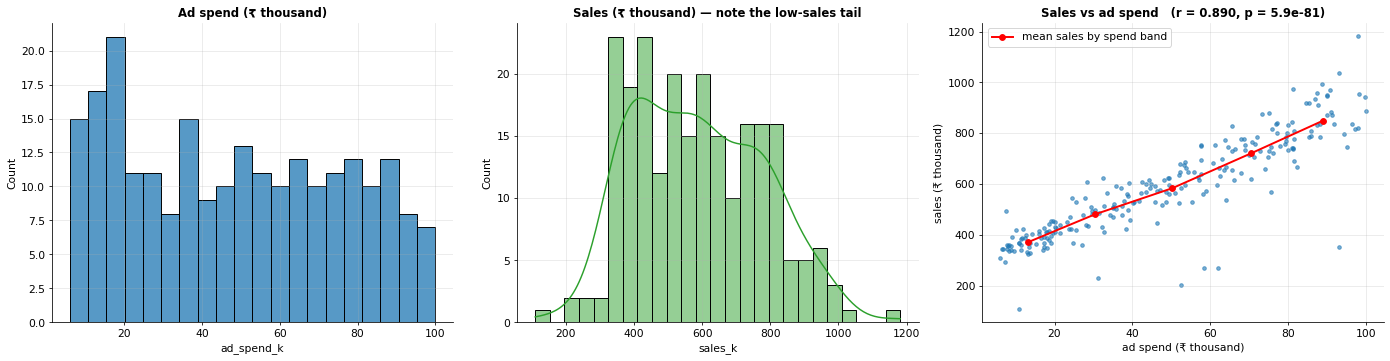

,x,mean_sales,sd_sales,n,sd / mean
band,,,,,
"(0, 20]",13.3038,372.4654,54.1118,52,0.1453
"(20, 40]",30.4167,481.4938,72.8514,48,0.1513
"(40, 60]",50.2761,584.2413,97.0569,46,0.1661
"(60, 80]",70.5479,721.6208,101.3107,48,0.1404
"(80, 100]",89.0359,850.1974,130.4799,39,0.1535


In [35]:
cs_all = cs.dropna().copy()          # a missing PREDICTOR can't be used in a simple regression; 7 rows dropped (only 2.9%, no obvious pattern)
r_, p_r = stats.pearsonr(cs_all["ad_spend_k"], cs_all["sales_k"])
cs_all["band"] = pd.cut(cs_all["ad_spend_k"], bins=[0, 20, 40, 60, 80, 100])
g = cs_all.groupby("band", observed=True).agg(x=("ad_spend_k", "mean"), mean_sales=("sales_k", "mean"), sd_sales=("sales_k", "std"), n=("sales_k", "size"))
g["sd / mean"] = g["sd_sales"] / g["mean_sales"]

fig, ax = plt.subplots(1, 3, figsize=(20, 5.3))
sns.histplot(cs_all["ad_spend_k"], bins=20, ax=ax[0], color="tab:blue"); ax[0].set_title("Ad spend (₹ thousand)")
sns.histplot(cs_all["sales_k"], bins=25, kde=True, ax=ax[1], color="tab:green"); ax[1].set_title("Sales (₹ thousand) — note the low-sales tail")
ax[2].scatter(cs_all["ad_spend_k"], cs_all["sales_k"], s=14, alpha=.6); ax[2].plot(g["x"], g["mean_sales"], "ro-", lw=2, label="mean sales by spend band")
ax[2].set(xlabel="ad spend (₹ thousand)", ylabel="sales (₹ thousand)", title=f"Sales vs ad spend   (r = {r_:.3f}, p = {p_r:.1e})"); ax[2].legend()
plt.tight_layout(); plt.show()
display(g)

**EDA findings**

| Observation | Meaning | Action |
|---|---|---|
| Strong, positive, roughly straight relationship ($r\approx0.9$) | Simple linear regression is reasonable | proceed |
| Spread of sales **widens** as spend grows, while `sd / mean` is roughly constant | Multiplicative noise ⇒ **heteroscedasticity** (assumption **E** at risk) | check formally; plan robust SEs or **WLS** |
| A handful of points far below (and a couple above) the cloud | Outliers: data errors or real events? | investigate before deleting |

### 10.6 Train / test split
We keep 20 % of the months untouched to measure honest, out-of-sample performance.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression, HuberRegressor

train, test = train_test_split(cs_all[["month_id", "ad_spend_k", "sales_k"]], test_size=0.2, random_state=3)
print(f"train = {len(train)} months, test = {len(test)} months")

# ---- a compact, transparent simple-OLS helper (everything from Sections 3–4 in one function)
def ols_simple(x, y, alpha=0.05):
    x = np.asarray(x, float); y = np.asarray(y, float); n = len(x)
    xbar, ybar = x.mean(), y.mean(); Sxx = ((x - xbar)**2).sum(); Sxy = ((x - xbar) * (y - ybar)).sum()
    b1 = Sxy / Sxx; b0 = ybar - b1 * xbar; fit = b0 + b1 * x; e = y - fit
    s2 = e @ e / (n - 2)
    return dict(n=n, xbar=xbar, ybar=ybar, Sxx=Sxx, b0=b0, b1=b1, fit=fit, e=e, s2=s2, s=np.sqrt(s2),
                se0=np.sqrt(s2 * (1 / n + xbar**2 / Sxx)), se1=np.sqrt(s2 / Sxx),
                tcrit=stats.t.ppf(1 - alpha / 2, n - 2), r2=1 - e @ e / ((y - ybar)**2).sum())

def coef_table(m):
    t0, t1 = m["b0"] / m["se0"], m["b1"] / m["se1"]
    return pd.DataFrame({"coef": [m["b0"], m["b1"]], "std err": [m["se0"], m["se1"]], "t": [t0, t1],
                         "P>|t|": [2 * stats.t.sf(abs(t0), m["n"] - 2), 2 * stats.t.sf(abs(t1), m["n"] - 2)],
                         "[0.025": [m["b0"] - m["tcrit"] * m["se0"], m["b1"] - m["tcrit"] * m["se1"]],
                         "0.975]": [m["b0"] + m["tcrit"] * m["se0"], m["b1"] + m["tcrit"] * m["se1"]]},
                        index=["const (baseline sales)", "ad_spend_k (slope)"])

train = 186 months, test = 47 months


### 10.7 Baseline model (fit on *all* training data, warts included)

R² = 0.760   residual std error s = 92.3   (true slope 6, true intercept 300)


,coef,std err,t,P>|t|,[0.025,0.975]
const (baseline sales),293.7942,13.9753,21.0223,0.0000,266.2217,321.3667
ad_spend_k (slope),6.0577,0.2509,24.1486,0.0000,5.5628,6.5526


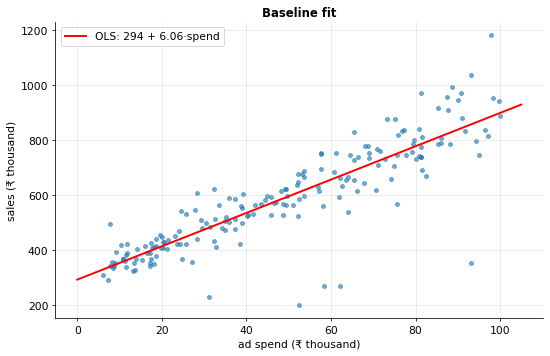

In [37]:
x_tr, y_tr = train["ad_spend_k"].values, train["sales_k"].values
m1 = ols_simple(x_tr, y_tr)
display(coef_table(m1))
print(f"R² = {m1['r2']:.3f}   residual std error s = {m1['s']:.1f}   (true slope 6, true intercept 300)")

g_ = np.linspace(0, 105, 50)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x_tr, y_tr, s=16, alpha=.6); ax.plot(g_, m1["b0"] + m1["b1"] * g_, "r", lw=2, label=f"OLS: {m1['b0']:.0f} + {m1['b1']:.2f}·spend")
ax.set(xlabel="ad spend (₹ thousand)", ylabel="sales (₹ thousand)", title="Baseline fit"); ax.legend(); plt.show()

The slope is already close to the truth — but *do not trust the standard errors yet*. Time for diagnostics.

### 10.8 Diagnostics of the baseline model
Six views: residuals vs fitted (linearity/variance), Q–Q (normality), histogram, scale–location, $|e|$ vs spend (does the spread grow?), and **Cook's distance** (which points steer the line?).

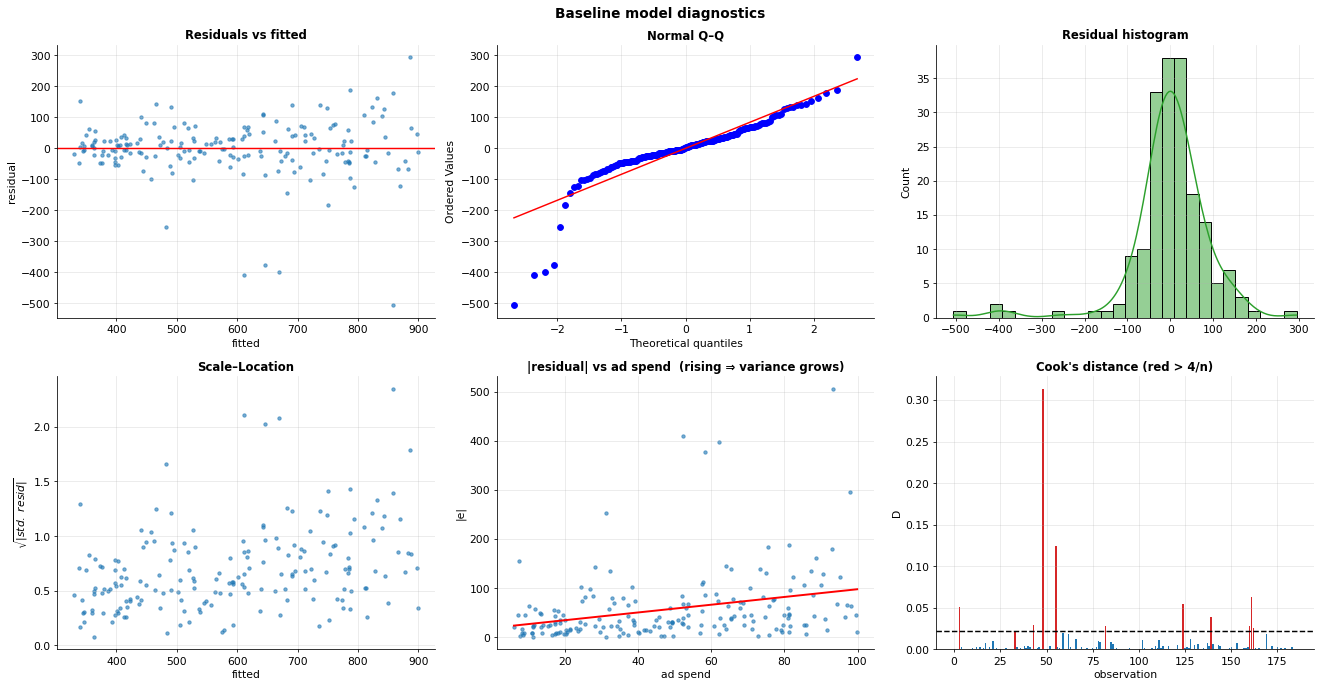

Breusch–Pagan p = 7.42e-03 (H0: constant variance) | Shapiro–Wilk p = 1.06e-13 (H0: normal) | skew = -1.92, excess kurtosis = 9.16


In [38]:
def bp_pvalue(x, e):                                              # Breusch–Pagan for one predictor
    X = np.c_[np.ones(len(x)), x]; e2 = e**2; b = np.linalg.lstsq(X, e2, rcond=None)[0]
    r2 = 1 - ((e2 - X @ b)**2).sum() / ((e2 - e2.mean())**2).sum(); return stats.chi2.sf(len(x) * r2, 1)

def cs_diag(x, m, title):
    e, fit, n, s2 = m["e"], m["fit"], m["n"], m["s2"]
    h = 1 / n + (x - m["xbar"])**2 / m["Sxx"]; cook = e**2 / (2 * s2) * h / (1 - h)**2
    fig, ax = plt.subplots(2, 3, figsize=(19, 10)); fig.suptitle(title, fontsize=14, fontweight="bold")
    ax[0, 0].scatter(fit, e, s=12, alpha=.6); ax[0, 0].axhline(0, color="r"); ax[0, 0].set(title="Residuals vs fitted", xlabel="fitted", ylabel="residual")
    stats.probplot(e, dist="norm", plot=ax[0, 1]); ax[0, 1].set_title("Normal Q–Q")
    sns.histplot(e, kde=True, ax=ax[0, 2], color="tab:green"); ax[0, 2].set_title("Residual histogram")
    ax[1, 0].scatter(fit, np.sqrt(np.abs(e / e.std())), s=12, alpha=.6); ax[1, 0].set(title="Scale–Location", xlabel="fitted", ylabel=r"$\sqrt{|std.\ resid|}$")
    c = np.polyfit(x, np.abs(e), 1); gg = np.linspace(x.min(), x.max(), 10)
    ax[1, 1].scatter(x, np.abs(e), s=12, alpha=.6); ax[1, 1].plot(gg, np.polyval(c, gg), "r", lw=2); ax[1, 1].set(title="|residual| vs ad spend  (rising ⇒ variance grows)", xlabel="ad spend", ylabel="|e|")
    ax[1, 2].bar(range(n), cook, color=np.where(cook > 4 / n, "tab:red", "tab:blue")); ax[1, 2].axhline(4 / n, color="k", ls="--"); ax[1, 2].set(title="Cook's distance (red > 4/n)", xlabel="observation", ylabel="D")
    plt.tight_layout(); plt.show()
    print(f"Breusch–Pagan p = {bp_pvalue(x, e):.2e} (H0: constant variance) | Shapiro–Wilk p = {stats.shapiro(e).pvalue:.2e} (H0: normal) | skew = {stats.skew(e):.2f}, excess kurtosis = {stats.kurtosis(e):.2f}")

cs_diag(x_tr, m1, "Baseline model diagnostics")

**What the plots say**
* **Residuals vs fitted** — a *funnel* (variance grows with fitted value) plus a group of points far below zero.
* **Q–Q / histogram** — heavy **left tail** (those low-sales months); normality clearly fails.
* **|e| vs spend** — an upward trend: textbook heteroscedasticity. **Breusch–Pagan** confirms it formally.
* **Cook's D** — a few observations have outsized influence.

Two separate problems, two separate treatments: **(1) outliers** (a few weird months), **(2) heteroscedasticity** (systematic, affects all data).

### 10.9 Problem 1 — investigate the outliers
Absolute residuals are inflated at high spend *because of the funnel*, so we screen the **relative residual** $u_i=e_i/\hat y_i$ (which is scale-free) with a **robust z-score** (median & MAD are not distorted by the outliers): $z_i=(u_i-\text{median}(u))/(1.4826\,\text{MAD}(u))$. Months with $|z|>3.5$ go to **manual review**.

> ⚠️ **Investigate before deleting.** A flag is a *question*, not a verdict. In this simulated review the operations team tells us: the months whose sales **collapsed** (negative $z$) were *stock-outs* — real events, but not the "normal advertising response" we want to model — so we exclude them **from this model**, document why, and hand them to a separate supply-chain analysis. The couple of *unusually strong* months (positive $z$) have no error or special cause — they are just extreme-but-legitimate variation — so we **keep** them. The same rule (with the median/MAD learned on *train*) is applied to the test set.

7 of 186 training months sent to review; 5 confirmed as stock-outs and excluded  |  true stock-out months in train: 5  |  caught: 5
Stock-outs excluded from test: 1  → clean train = 181, clean test = 46


,month_id,ad_spend_k,sales_k,expected_sales,actual_vs_expected_pct,z,verdict
133,134,58.3000,270.5000,647.0000,-58.0000,-6.4000,stock-out → exclude
13,14,31.2000,230.4000,483.0000,-52.0000,-5.8000,stock-out → exclude
5,6,93.2000,352.4000,858.0000,-59.0000,-6.5000,stock-out → exclude
81,82,97.9000,"1,181.6000",887.0000,33.0000,3.6000,unusually strong month → keep
1,2,52.4000,202.0000,611.0000,-67.0000,-7.4000,stock-out → exclude
2,3,62.1000,271.8000,670.0000,-59.0000,-6.6000,stock-out → exclude
69,70,7.6000,494.1000,340.0000,45.0000,4.9000,unusually strong month → keep


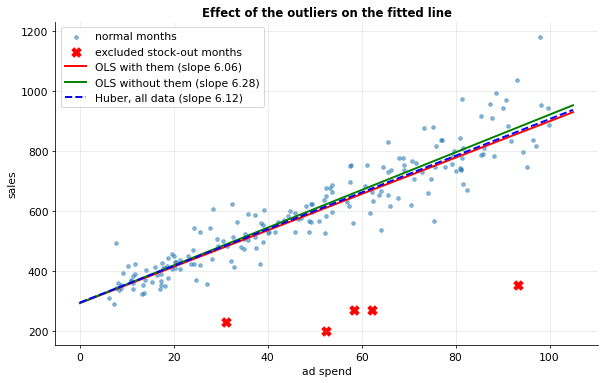

In [39]:
pct = m1["e"] / m1["fit"]                                       # relative residual
med, mad = np.median(pct), 1.4826 * np.median(np.abs(pct - np.median(pct)))
z = (pct - med) / mad
review = np.abs(z) > 3.5                                        # candidates for manual review
flag_tr = z < -3.5                                              # confirmed stock-outs (sales collapse) → excluded from the model
print(f"{review.sum()} of {len(train)} training months sent to review; {flag_tr.sum()} confirmed as stock-outs and excluded  |  true stock-out months in train: {np.isin(train.index, disrupt).sum()}  |  caught: {np.isin(train.index[flag_tr], disrupt).sum()}")
rev = train[review].assign(expected_sales=m1["fit"][review].round(0), actual_vs_expected_pct=(pct[review] * 100).round(0), z=z[review].round(1))
rev["verdict"] = np.where(rev["z"] < 0, "stock-out → exclude", "unusually strong month → keep")
display(rev)

# same rule for the test set (model & scale learned on train only)
pred_te_m1 = m1["b0"] + m1["b1"] * test["ad_spend_k"].values
flag_te = ((test["sales_k"].values - pred_te_m1) / pred_te_m1 - med) / mad < -3.5
train_c, test_c = train[~flag_tr], test[~flag_te]
print(f"Stock-outs excluded from test: {flag_te.sum()}  → clean train = {len(train_c)}, clean test = {len(test_c)}")

# How much do they matter?  OLS with them, OLS without them, Huber (robust loss) with them
x_c, y_c = train_c["ad_spend_k"].values, train_c["sales_k"].values
m2 = ols_simple(x_c, y_c)
hub = HuberRegressor(epsilon=1.35).fit(x_tr.reshape(-1, 1), y_tr)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_c, y_c, s=14, alpha=.5, label="normal months"); ax.scatter(x_tr[flag_tr], y_tr[flag_tr], s=90, color="red", marker="X", label="excluded stock-out months")
ax.plot(g_, m1["b0"] + m1["b1"] * g_, "r", lw=2, label=f"OLS with them (slope {m1['b1']:.2f})")
ax.plot(g_, m2["b0"] + m2["b1"] * g_, "g", lw=2, label=f"OLS without them (slope {m2['b1']:.2f})")
ax.plot(g_, hub.intercept_ + hub.coef_[0] * g_, "b--", lw=2, label=f"Huber, all data (slope {hub.coef_[0]:.2f})")
ax.set(xlabel="ad spend", ylabel="sales", title="Effect of the outliers on the fitted line"); ax.legend(); plt.show()

The outliers *pull the line down* and shrink the slope (biasing the ROI estimate downward!). Huber gets close to the clean fit automatically — a good sanity check that our exclusion isn't cherry-picking.

### 10.10 Refit on clean data and re-check

R² = 0.874   s = 64.8   (true slope 6, intercept 300)


,coef,std err,t,P>|t|,[0.025,0.975]
const (baseline sales),293.9210,9.8746,29.7654,0.0000,274.4354,313.4065
ad_spend_k (slope),6.2766,0.1779,35.2810,0.0000,5.9255,6.6276


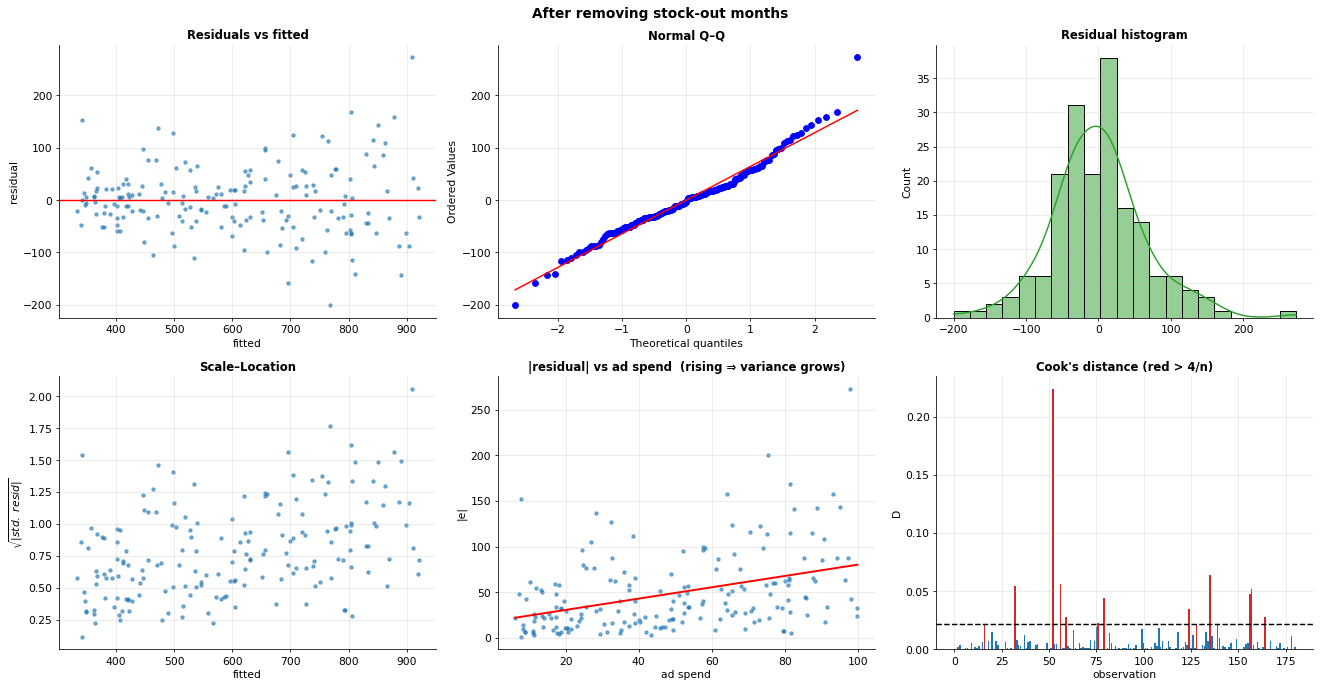

Breusch–Pagan p = 1.54e-05 (H0: constant variance) | Shapiro–Wilk p = 2.97e-03 (H0: normal) | skew = 0.46, excess kurtosis = 1.75


In [40]:
display(coef_table(m2))
print(f"R² = {m2['r2']:.3f}   s = {m2['s']:.1f}   (true slope 6, intercept 300)")
cs_diag(x_c, m2, "After removing stock-out months")

The stock-out outliers are gone: the Q–Q plot is nearly straight (the small right tail comes from the unusually strong month we deliberately kept) and the largest Cook's D is about 0.2, far below the worry level of 1. But the **funnel remains**: variance still grows with spend.

### 10.11 Problem 2 — heteroscedasticity: *what breaks and what doesn't*
* The OLS **coefficients are still unbiased and consistent** ✅
* The classical **standard errors, t-tests, confidence intervals and especially prediction intervals are wrong** ❌ — the classical prediction interval has *constant width*, so it is **too wide at low spend and too narrow at high spend**.

Let's measure this. We compute the empirical coverage of the classical 95 % prediction interval within three spend bands (should be ≈ 95 % in each):

In [41]:
def pi_classical(m, x0):
    x0 = np.asarray(x0, float); f = m["b0"] + m["b1"] * x0
    half = m["tcrit"] * m["s"] * np.sqrt(1 + 1 / m["n"] + (x0 - m["xbar"])**2 / m["Sxx"]); return f - half, f + half

bands = [0, 35, 70, 100.01]; labels = ["low (<35)", "mid (35–70)", "high (>70)"]
def coverage(x, y, lo, hi):
    d = pd.DataFrame({"inside": (y >= lo) & (y <= hi), "width": hi - lo, "band": pd.cut(x, bins=bands, labels=labels, right=False)})
    out = d.groupby("band", observed=True).agg(coverage=("inside", "mean"), mean_width=("width", "mean"), n=("inside", "size"))
    out.loc["ALL"] = [d["inside"].mean(), d["width"].mean(), len(d)]; return out

lo, hi = pi_classical(m2, x_c)
cov_classic_train = coverage(x_c, y_c, lo, hi)
display(cov_classic_train.style.format({"coverage": "{:.1%}", "mean_width": "{:.0f}"}))

,coverage,mean_width,n
band,,,
low (<35),97.1%,257,68.000000
mid (35–70),98.4%,257,64.000000
high (>70),85.7%,258,49.000000
ALL,94.5%,257,181.000000


Exactly as predicted: the constant-width "95 %" interval **over-covers at low/mid spend (≈ 97 %) and under-covers at high spend (≈ 85 %)**. Overall it looks fine (≈ 94 %) — the problem is hidden in the *average*. For budgeting at high spend levels this would be dangerously optimistic.

### 10.12 Two remedies

**(a) Robust ("sandwich", HC3) standard errors** — keep the OLS line, but estimate its uncertainty *without* assuming constant variance:
$$\widehat{\text{Cov}}(\hat{\boldsymbol\beta})=(\mathbf X^\top\mathbf X)^{-1}\Big[\sum_i \frac{e_i^2}{(1-h_{ii})^2}\,\mathbf x_i\mathbf x_i^\top\Big](\mathbf X^\top\mathbf X)^{-1}$$

**(b) Weighted Least Squares (WLS)** — give noisy observations *less weight*. If $\text{Var}(\varepsilon_i)=\sigma_i^2$, minimise
$$\text{WSSE}=\sum_i w_i\,e_i^2,\quad w_i=\frac1{\sigma_i^2}\ \Longrightarrow\ \hat{\boldsymbol\beta}_{WLS}=(\mathbf X^\top\mathbf W\mathbf X)^{-1}\mathbf X^\top\mathbf W\mathbf y$$
(BLUE when the weights are right.) Since $\sigma_i$ is unknown we estimate it: regress $|e_i|$ on spend (because $E|e|=\sigma\sqrt{2/\pi}$), rescale to get $\hat\sigma(x)$, set $w=1/\hat\sigma(x)^2$, and iterate a few times (**Feasible GLS**). *Intuition:* WLS trusts the precise low-spend months more, and this yields a **tighter slope estimate** *and* correct, **variable-width prediction intervals**.

scikit-learn supports this via `fit(..., sample_weight=w)`; statsmodels via `sm.WLS(y, X, weights=w)`.

intercepts → OLS: 293.92 | WLS: 298.49   (true 300, slope 6)
sklearn LinearRegression(sample_weight=w): intercept = 298.4938, slope = 6.1720   |  by hand: 298.4938, 6.1720


,slope,std err,95% CI low,95% CI high,CI width
"OLS, classical SE",6.2766,0.1779,5.9255,6.6276,0.7021
"OLS, robust HC3 SE",6.2766,0.2117,5.8617,6.6914,0.8297
WLS (weights ∝ 1/σ̂²),6.1720,0.1734,5.8298,6.5142,0.6844


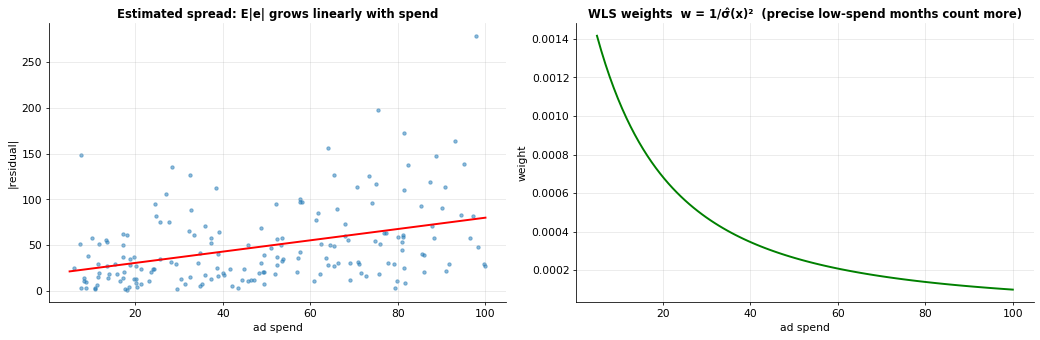

In [42]:
X_c = np.c_[np.ones(len(x_c)), x_c]

# ---- (a) HC3 robust SEs (by hand)
def hc3_cov(X, e, XtXi):
    h = np.einsum("ij,jk,ik->i", X, XtXi, X); u = (e / (1 - h))**2
    return XtXi @ (X.T @ (X * u[:, None])) @ XtXi
XtXi = np.linalg.inv(X_c.T @ X_c)
se_hc3 = np.sqrt(np.diag(hc3_cov(X_c, m2["e"], XtXi)))

# ---- (b) WLS via feasible GLS (by hand)
def fgls(x, y, iters=3):
    X = np.c_[np.ones(len(x)), x]; b = np.linalg.lstsq(X, y, rcond=None)[0]
    for _ in range(iters):
        e = y - X @ b
        c = np.polyfit(x, np.abs(e), 1)                                           # E|e| ≈ c0 + c1·x
        sig = np.clip(np.polyval(c, x), 1e-3, None) * np.sqrt(np.pi / 2)          # σ̂(x)
        w = 1 / sig**2; A = X.T @ (X * w[:, None]); b = np.linalg.solve(A, X.T @ (w * y))
    e = y - X @ b; s2 = (w * e**2).sum() / (len(y) - 2)
    return dict(b=b, w=w, c=c, A=A, s2=s2, cov=s2 * np.linalg.inv(A), e=e, n=len(y))

mw = fgls(x_c, y_c)
se_wls = np.sqrt(np.diag(mw["cov"]))
t_w = stats.t.ppf(.975, mw["n"] - 2)

cmp = pd.DataFrame({
    "slope": [m2["b1"], m2["b1"], mw["b"][1]],
    "std err": [m2["se1"], se_hc3[1], se_wls[1]],
    "95% CI low":  [m2["b1"] - m2["tcrit"] * m2["se1"], m2["b1"] - 1.96 * se_hc3[1], mw["b"][1] - t_w * se_wls[1]],
    "95% CI high": [m2["b1"] + m2["tcrit"] * m2["se1"], m2["b1"] + 1.96 * se_hc3[1], mw["b"][1] + t_w * se_wls[1]],
}, index=["OLS, classical SE", "OLS, robust HC3 SE", "WLS (weights ∝ 1/σ̂²)"])
cmp["CI width"] = cmp["95% CI high"] - cmp["95% CI low"]
display(cmp)
print("intercepts → OLS:", round(m2["b0"], 2), "| WLS:", round(mw["b"][0], 2), "  (true 300, slope 6)")

# sklearn WLS gives the same coefficients:
sk_w = LinearRegression().fit(x_c.reshape(-1, 1), y_c, sample_weight=mw["w"])
print(f"sklearn LinearRegression(sample_weight=w): intercept = {sk_w.intercept_:.4f}, slope = {sk_w.coef_[0]:.4f}   |  by hand: {mw['b'][0]:.4f}, {mw['b'][1]:.4f}")

# picture: weights & variance function
gg = np.linspace(5, 100, 100)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(x_c, np.abs(mw["e"]), s=12, alpha=.5); ax[0].plot(gg, np.polyval(mw["c"], gg), "r", lw=2); ax[0].set(title="Estimated spread: E|e| grows linearly with spend", xlabel="ad spend", ylabel="|residual|")
ax[1].plot(gg, 1 / (np.clip(np.polyval(mw["c"], gg), 1e-3, None) * np.sqrt(np.pi / 2))**2, "g", lw=2); ax[1].set(title="WLS weights  w = 1/σ̂(x)²  (precise low-spend months count more)", xlabel="ad spend", ylabel="weight")
plt.tight_layout(); plt.show()

**Reading the table:** all three slopes agree (unbiasedness), but the *uncertainty* differs. Robust SEs correct the classical SE (usually upward when the noisiest points are also the most extreme in $x$); WLS is typically the **most precise** because it uses the variance structure.

Now build the WLS **prediction interval**. For a new month with spend $x_0$:
$$\text{Var}(y_0-\hat y_0)=\underbrace{s^2\hat\sigma(x_0)^2}_{\text{noise of one new month (depends on }x_0!)}+\underbrace{\mathbf x_0^\top\widehat{\text{Cov}}(\hat{\boldsymbol\beta})\,\mathbf x_0}_{\text{uncertainty of the line}}$$

,coverage (classical),mean_width (classical),n (classical),coverage (WLS),mean_width (WLS),n (WLS)
band,,,,,,
low (<35),97.1%,257,68,92.6%,161,68
mid (35–70),98.4%,257,64,96.9%,269,64
high (>70),85.7%,258,49,95.9%,372,49
ALL,94.5%,257,181,95.0%,256,181


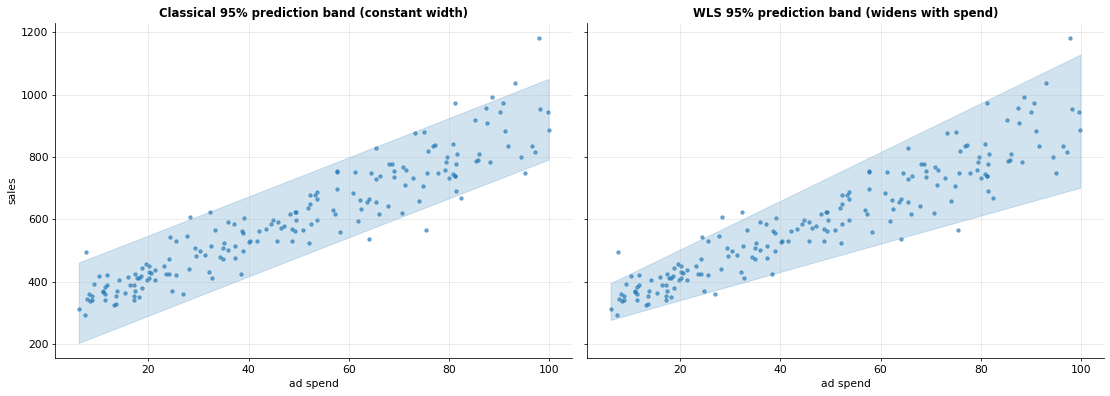

In [43]:
def pi_wls(mw, x0, level=0.95):
    x0 = np.asarray(x0, float); X0 = np.c_[np.ones(len(x0)), x0]; f = X0 @ mw["b"]
    var_mean = np.einsum("ij,jk,ik->i", X0, mw["cov"], X0)
    sig = np.clip(np.polyval(mw["c"], x0), 1e-3, None) * np.sqrt(np.pi / 2)
    half = stats.t.ppf(1 - (1 - level) / 2, mw["n"] - 2) * np.sqrt(mw["s2"] * sig**2 + var_mean); return f - half, f + half

lo_w, hi_w = pi_wls(mw, x_c)
cov_wls_train = coverage(x_c, y_c, lo_w, hi_w)
out = cov_classic_train.join(cov_wls_train, lsuffix=" (classical)", rsuffix=" (WLS)")
display(out.style.format({"coverage (classical)": "{:.1%}", "coverage (WLS)": "{:.1%}", "mean_width (classical)": "{:.0f}", "mean_width (WLS)": "{:.0f}", "n (classical)": "{:.0f}", "n (WLS)": "{:.0f}"}))

fig, ax = plt.subplots(1, 2, figsize=(16, 5.8), sharey=True)
for a_, (l, h_), ttl in [(ax[0], (lo, hi), "Classical 95% prediction band (constant width)"), (ax[1], (lo_w, hi_w), "WLS 95% prediction band (widens with spend)")]:
    o = np.argsort(x_c); a_.scatter(x_c, y_c, s=12, alpha=.6); a_.fill_between(x_c[o], l[o], h_[o], color="tab:blue", alpha=.2); a_.set(title=ttl, xlabel="ad spend")
ax[0].set_ylabel("sales"); plt.tight_layout(); plt.show()

The WLS interval has **close to 95 % coverage in every band** (roughly 92–97 %, versus 85 % for the classical interval at high spend) and its width follows the data: narrow at low spend, wide at high spend. This is what "honest uncertainty" looks like.

### 10.13 statsmodels: confirm everything and get the formal tables
The same three analyses in statsmodels (Section 7 explains every field of the summary).

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
Xsm = sm.add_constant(pd.DataFrame({"ad_spend_k": x_c}))
ols_cs = sm.OLS(y_c, Xsm).fit()
print(ols_cs.summary())

ols_cs_hc3 = sm.OLS(y_c, Xsm).fit(cov_type="HC3")
wls_cs = sm.WLS(y_c, Xsm, weights=mw["w"]).fit()
print("\n--- OLS with robust HC3 standard errors ---");  print(ols_cs_hc3.summary().tables[1])
print("\n--- WLS with estimated weights ---");           print(wls_cs.summary().tables[1])

bp = het_breuschpagan(ols_cs.resid, ols_cs.model.exog)
print(f"\nBreusch–Pagan LM = {bp[0]:.2f}, p = {bp[1]:.2e}  → heteroscedasticity confirmed")
print("Matches by-hand results?  OLS coef:", np.allclose(ols_cs.params, [m2['b0'], m2['b1']]),
      "| classical SE:", np.allclose(ols_cs.bse, [m2['se0'], m2['se1']]),
      "| HC3 SE:", np.allclose(ols_cs_hc3.bse, se_hc3),
      "| WLS coef:", np.allclose(wls_cs.params, mw['b']), "| WLS SE:", np.allclose(wls_cs.bse, se_wls))

### 10.14 Answering the boss's question: *is advertising profitable?*
Profit per extra ₹1 of advertising $=0.25\cdot\beta_1-1$. Advertising pays off iff $\beta_1>4$.

One-sided hypothesis test: $H_0:\ \beta_1\le4$ versus $H_1:\ \beta_1>4$, with
$$t=\frac{\hat\beta_1-4}{\text{SE}(\hat\beta_1)},\qquad p=P(T_{n-2}>t)$$
A one-sided 95 % **lower confidence bound** $\hat\beta_1-t_{0.95}\text{SE}$ above 4 tells the same story in business terms: *"even in a pessimistic reading, each ₹1 of ads returns at least ₹X in sales."*

,slope β̂₁,SE,t (vs 4),one-sided p,95% lower bound,profit per ₹1 ads (est.),profit per ₹1 (pessimistic)
method,,,,,,,
OLS (classical SE),6.2766,0.1779,12.7967,0.0000,5.9824,0.5691,0.4956
OLS (robust HC3 SE),6.2766,0.2117,10.7560,0.0000,5.9266,0.5691,0.4817
WLS,6.1720,0.1734,12.5256,0.0000,5.8853,0.5430,0.4713


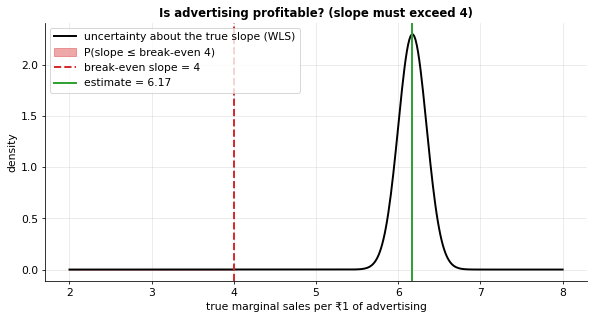

In [44]:
margin, breakeven = 0.25, 1 / 0.25
rows = []
for name, b1_, se_, df_ in [("OLS (classical SE)", m2["b1"], m2["se1"], m2["n"] - 2), ("OLS (robust HC3 SE)", m2["b1"], se_hc3[1], m2["n"] - 2), ("WLS", mw["b"][1], se_wls[1], mw["n"] - 2)]:
    t_ = (b1_ - breakeven) / se_; p_ = stats.t.sf(t_, df_); lb = b1_ - stats.t.ppf(.95, df_) * se_
    rows.append({"method": name, "slope β̂₁": b1_, "SE": se_, "t (vs 4)": t_, "one-sided p": p_, "95% lower bound": lb, "profit per ₹1 ads (est.)": margin * b1_ - 1, "profit per ₹1 (pessimistic)": margin * lb - 1})
res = pd.DataFrame(rows).set_index("method"); display(res)

b1_, se_ = mw["b"][1], se_wls[1]; gx = np.linspace(2, 8, 400)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(gx, stats.t.pdf((gx - b1_) / se_, mw["n"] - 2) / se_, "k", lw=2, label="uncertainty about the true slope (WLS)")
ax.fill_between(gx, stats.t.pdf((gx - b1_) / se_, mw["n"] - 2) / se_, where=gx <= breakeven, color="tab:red", alpha=.4, label="P(slope ≤ break-even 4)")
ax.axvline(breakeven, color="tab:red", ls="--", lw=2, label="break-even slope = 4"); ax.axvline(b1_, color="tab:green", lw=2, label=f"estimate = {b1_:.2f}")
ax.set(xlabel="true marginal sales per ₹1 of advertising", ylabel="density", title="Is advertising profitable? (slope must exceed 4)"); ax.legend(); plt.show()

**Conclusion:** the slope is far above the break-even value of 4, the p-value is essentially 0, and even the pessimistic lower bound leaves each ₹1 of advertising profitable. *Statistically and commercially significant.* (Note how the estimated ROI would have been **understated** had we ignored the stock-out months.)

### 10.15 Predictive validation on the untouched test set
We now compare three predictors on the clean test months in **₹ thousand**: (0) "always predict the average sales", (1) OLS line, (2) WLS line.

Point predictions from OLS and WLS are almost identical — the real gain from WLS is in the UNCERTAINTY (intervals & SEs), not in the point forecast.
(Only ~15 test months per band, so each percentage is noisy; look at the overall pattern.)


,RMSE,MAE,MAPE (%),R²
0. average only,191.5214,169.2696,31.9886,-0.0000
1. OLS line,50.5507,37.9299,6.6343,0.9303
2. WLS line,50.8681,37.7913,6.5681,0.9295


,coverage (classical),mean_width (classical),n (classical),coverage (WLS),mean_width (WLS),n (WLS)
band,,,,,,
low (<35),100.0%,257,17,100.0%,153,17
mid (35–70),93.3%,257,15,93.3%,268,15
high (>70),100.0%,258,14,100.0%,374,14
ALL,97.8%,257,46,97.8%,258,46


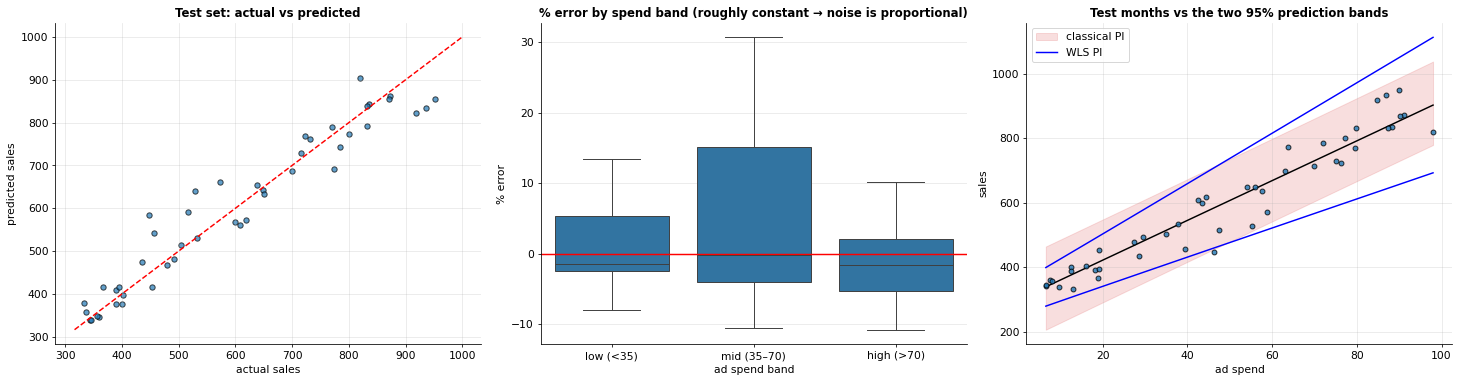

In [45]:
x_te, y_te = test_c["ad_spend_k"].values, test_c["sales_k"].values
pred_ols = m2["b0"] + m2["b1"] * x_te; pred_wls = mw["b"][0] + mw["b"][1] * x_te

def report(y_t, y_p):
    return {"RMSE": np.sqrt(metrics.mean_squared_error(y_t, y_p)), "MAE": metrics.mean_absolute_error(y_t, y_p),
            "MAPE (%)": metrics.mean_absolute_percentage_error(y_t, y_p) * 100, "R²": metrics.r2_score(y_t, y_p)}
display(pd.DataFrame({"0. average only": report(y_te, np.full_like(y_te, y_c.mean())), "1. OLS line": report(y_te, pred_ols), "2. WLS line": report(y_te, pred_wls)}).T)
print("Point predictions from OLS and WLS are almost identical — the real gain from WLS is in the UNCERTAINTY (intervals & SEs), not in the point forecast.")

# out-of-sample interval coverage per band
lo_c, hi_c = pi_classical(m2, x_te); lo_w2, hi_w2 = pi_wls(mw, x_te)
cv = coverage(x_te, y_te, lo_c, hi_c).join(coverage(x_te, y_te, lo_w2, hi_w2), lsuffix=" (classical)", rsuffix=" (WLS)")
display(cv.style.format({"coverage (classical)": "{:.1%}", "coverage (WLS)": "{:.1%}", "mean_width (classical)": "{:.0f}", "mean_width (WLS)": "{:.0f}", "n (classical)": "{:.0f}", "n (WLS)": "{:.0f}"}))
print("(Only ~15 test months per band, so each percentage is noisy; look at the overall pattern.)")

fig, ax = plt.subplots(1, 3, figsize=(21, 5.6))
lim = [y_te.min() * .95, y_te.max() * 1.05]
ax[0].scatter(y_te, pred_wls, s=30, edgecolor="k", alpha=.7); ax[0].plot(lim, lim, "r--"); ax[0].set(xlabel="actual sales", ylabel="predicted sales", title="Test set: actual vs predicted")
pe = (pred_wls - y_te) / y_te * 100
sns.boxplot(x=pd.cut(x_te, bins=bands, labels=labels, right=False), y=pe, ax=ax[1], color="tab:blue"); ax[1].axhline(0, color="r"); ax[1].set(title="% error by spend band (roughly constant → noise is proportional)", ylabel="% error", xlabel="ad spend band")
o = np.argsort(x_te); ax[2].scatter(x_te, y_te, s=25, edgecolor="k", alpha=.8, zorder=3)
ax[2].fill_between(x_te[o], lo_c[o], hi_c[o], color="tab:red", alpha=.15, label="classical PI"); ax[2].plot(x_te[o], lo_w2[o], "b"); ax[2].plot(x_te[o], hi_w2[o], "b", label="WLS PI"); ax[2].plot(x_te[o], pred_wls[o], "k", lw=1.5)
ax[2].set(xlabel="ad spend", ylabel="sales", title="Test months vs the two 95% prediction bands"); ax[2].legend()
plt.tight_layout(); plt.show()

### 10.16 Turning the model into a decision tool

**(1) Response curve** with the confidence band for the *average* month and the prediction band for an *individual* month.
**(2) Budget planner** — "how much must we spend to reach a sales target?" Two answers:
* **Expected-value spend:** solve $y^*=\hat\beta_0+\hat\beta_1x\Rightarrow x^*=(y^*-\hat\beta_0)/\hat\beta_1$ (on average we hit the target).
* **95 %-safe spend:** the smallest spend whose **lower prediction bound** is ≥ target (we hit it in a *single month* with ~95 % probability — one-sided ≈ 97.5 %).

**(3) Incremental profit** from advertising versus spending nothing: $(0.25\hat\beta_1-1)\,x$, with its uncertainty from the slope's CI.

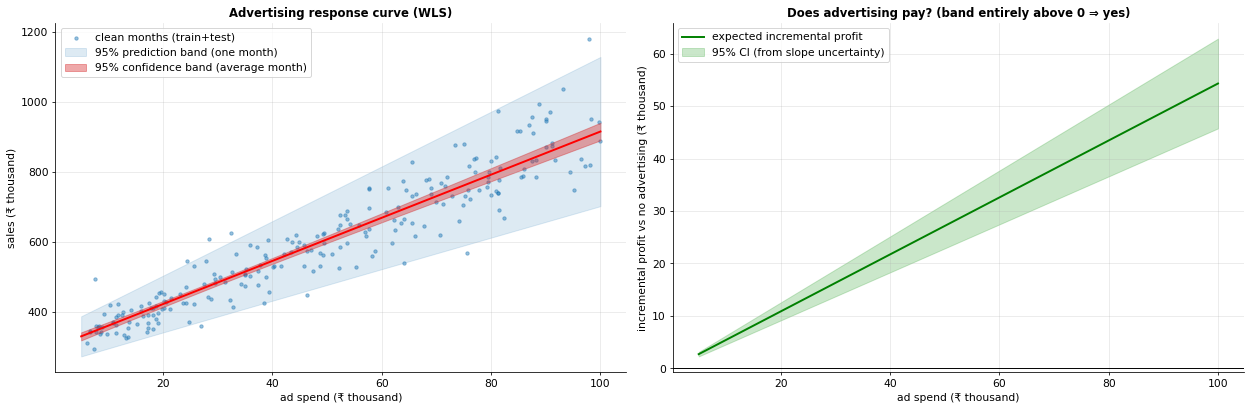

Expected-value spend above 100 or 'not reachable' means we would be EXTRAPOLATING beyond the data range – not trustworthy (real ad response usually saturates).


,spend for expected target,spend to be 95%-safe
target sales,,
450,24.5,44.3
550,40.7,66.4
650,57.0,88.6
750,73.2,not reachable within 5–100
850,89.4,not reachable within 5–100


In [46]:
gx = np.linspace(5, 100, 400); Xg = np.c_[np.ones(len(gx)), gx]
f = Xg @ mw["b"]; se_mean = np.sqrt(np.einsum("ij,jk,ik->i", Xg, mw["cov"], Xg))
ci_lo, ci_hi = f - t_w * se_mean, f + t_w * se_mean
pi_lo, pi_hi = pi_wls(mw, gx)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].scatter(np.r_[x_c, x_te], np.r_[y_c, y_te], s=12, alpha=.45, label="clean months (train+test)")
ax[0].fill_between(gx, pi_lo, pi_hi, color="tab:blue", alpha=.15, label="95% prediction band (one month)")
ax[0].fill_between(gx, ci_lo, ci_hi, color="tab:red", alpha=.4, label="95% confidence band (average month)"); ax[0].plot(gx, f, "r", lw=2)
ax[0].set(xlabel="ad spend (₹ thousand)", ylabel="sales (₹ thousand)", title="Advertising response curve (WLS)"); ax[0].legend(loc="upper left")

inc = (margin * mw["b"][1] - 1) * gx; inc_lo = (margin * (mw["b"][1] - t_w * se_wls[1]) - 1) * gx; inc_hi = (margin * (mw["b"][1] + t_w * se_wls[1]) - 1) * gx
ax[1].plot(gx, inc, "g", lw=2, label="expected incremental profit"); ax[1].fill_between(gx, inc_lo, inc_hi, color="tab:green", alpha=.25, label="95% CI (from slope uncertainty)")
ax[1].axhline(0, color="k", lw=1); ax[1].set(xlabel="ad spend (₹ thousand)", ylabel="incremental profit vs no advertising (₹ thousand)", title="Does advertising pay? (band entirely above 0 ⇒ yes)"); ax[1].legend()
plt.tight_layout(); plt.show()

plan = []
for target in [450, 550, 650, 750, 850]:
    x_exp = (target - mw["b"][0]) / mw["b"][1]
    ok = gx[pi_lo >= target]; x_safe = ok.min() if len(ok) else np.nan
    plan.append({"target sales": target, "spend for expected target": x_exp, "spend to be 95%-safe": x_safe})
plan = pd.DataFrame(plan).set_index("target sales"); display(plan.style.format("{:.1f}", na_rep="not reachable within 5–100"))
print("Expected-value spend above 100 or 'not reachable' means we would be EXTRAPOLATING beyond the data range – not trustworthy (real ad response usually saturates).")

### 10.17 Conclusions, limitations, next steps

**Findings for the marketing director**
1. **Each extra ₹1,000 of advertising is associated with about ₹6,000 more monthly sales** (95 % CI roughly ₹5.8–6.5 thousand), on top of a baseline of ≈ ₹300 thousand with no advertising.
2. **Advertising is profitable**: break-even needs a slope of 4; the estimate is ≈ 6 and the p-value ≈ 0. Expected extra profit ≈ ₹0.54 per ₹1 spent.
3. **Budget planning:** use the table above; for a *guaranteed* month, budget noticeably more than the expected-value spend, and more so at high spend levels, where month-to-month variation is bigger.
4. **Data-quality lesson:** stock-out months (sales 40 % of normal) would have **understated** the ROI if left in; and the two unusually strong months were *kept* because extreme is not the same as wrong.

**Statistical lessons illustrated**
* Diagnose before you trust; classical SEs/intervals assume equal variance.
* **Outliers ≠ deletions**: investigate, document, and cross-check with a robust loss (Huber).
* Under heteroscedasticity, OLS coefficients remain fine but **inference needs HC3 or WLS**; only intervals change noticeably.
* Never confuse a confidence interval for the mean with a prediction interval for an individual.

**Caveats**
* **Correlation ≠ causation.** Stores may advertise more in busy seasons (confounding). A randomised test or controlling for season/store would be needed for a causal ROI.
* **Extrapolation** beyond ₹5–100 thousand is unsupported; real advertising has **diminishing returns** (check for curvature, or model with log–log — Section 9).
* Sales are also driven by price, seasonality, competitors… → **multiple regression** is the natural next step.
* This data is **simulated**; real data will show lower $R^2$ and messier residuals.

---
## 11. Cheat-sheet, Pitfalls & Exercises

### 11.1 Formula sheet (simple linear regression)
| Concept | Formula |
|---|---|
| Model | $y_i=\beta_0+\beta_1x_i+\varepsilon_i,\ \varepsilon_i\sim\mathcal N(0,\sigma^2)$ |
| Slope / intercept | $\hat\beta_1=\dfrac{S_{xy}}{S_{xx}}=r\dfrac{s_y}{s_x},\quad\hat\beta_0=\bar y-\hat\beta_1\bar x$ |
| Matrix form | $\hat{\boldsymbol\beta}=(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y$ |
| Residual, SSE, MSE, RMSE, MAE | $e_i=y_i-\hat y_i;\ \sum e_i^2;\ \frac1n\sum e_i^2;\ \sqrt{\text{MSE}};\ \frac1n\sum\lvert e_i\rvert$ |
| $R^2$ (= $r^2$) / adjusted | $1-\text{SSE}/\text{SST};\ \ 1-(1-R^2)\frac{n-1}{n-2}$ |
| Error variance | $s^2=\text{SSE}/(n-2)$ |
| Standard errors | $\text{SE}(\hat\beta_1)=\dfrac{s}{\sqrt{S_{xx}}},\ \ \text{SE}(\hat\beta_0)=s\sqrt{\dfrac1n+\dfrac{\bar x^2}{S_{xx}}}$ |
| t-test / CI | $t=\hat\beta_1/\text{SE};\ \ \hat\beta_1\pm t_{\alpha/2,n-2}\text{SE}$ |
| F-test | $F=\dfrac{\text{SSR}}{\text{SSE}/(n-2)}=t^2$ |
| CI for mean at $x_0$ | $\hat y_0\pm t\,s\sqrt{\frac1n+\frac{(x_0-\bar x)^2}{S_{xx}}}$ |
| PI for new $y$ at $x_0$ | $\hat y_0\pm t\,s\sqrt{1+\frac1n+\frac{(x_0-\bar x)^2}{S_{xx}}}$ |
| Leverage / Cook's D | $h_{ii}=\frac1n+\frac{(x_i-\bar x)^2}{S_{xx}};\ \ D_i=\dfrac{e_i^2}{2s^2}\dfrac{h_{ii}}{(1-h_{ii})^2}$ |
| Gradient descent | $\beta_0\leftarrow\beta_0-\eta\,\overline{(\hat y-y)},\ \ \beta_1\leftarrow\beta_1-\eta\,\overline{(\hat y-y)x}$ |
| WLS | $(\mathbf X^\top\mathbf W\mathbf X)^{-1}\mathbf X^\top\mathbf W\mathbf y,\ w_i=1/\sigma_i^2$ |
| AIC / BIC | $2k-2\ell;\ \ k\ln n-2\ell$ |

### 11.2 Common pitfalls
1. Trusting $R^2$ or $r$ without **plotting** (Anscombe!). 2. Interpreting the slope as **causal**. 3. **Extrapolating** beyond the observed range of $x$ (and interpreting the intercept when $x=0$ is far outside the data). 4. Ignoring heteroscedasticity → wrong CIs/PIs. 5. Confusing **CI (mean)** with **PI (individual)**. 6. Deleting outliers without investigation. 7. Judging on training error only — use a test set / CV. 8. Forgetting `sm.add_constant`. 9. Forcing the intercept to 0. 10. Noise in $x$ (attenuated slope). 11. Reading "not significant" as "no effect" — look at the CI. 12. Reversing the regression ($x$ on $y$) and expecting the inverse line.

### 11.3 Exercises
1. In Section 3.4, run gradient descent on the *unscaled* $x$ with `lr=0.06`. Why does it diverge? Compute $2/\lambda_{max}$.
2. In Section 2.8 add 10 outliers instead of 2. Which loss (MSE / MAE / Huber) breaks first?
3. Prove that residuals sum to zero (hint: first normal equation) and that $\sum x_ie_i=0$.
4. Show algebraically that $F=t^2$ for the slope in simple regression, and that $R^2=r^2$.
5. In the case study, re-fit with **log–log** (when you later move to many features) instead of WLS. Are residuals homoscedastic? How would you interpret the slope (elasticity)?
6. Bootstrap the slope (resample rows 2,000 times) and compare the percentile CI with the OLS/HC3/WLS intervals.
7. In the case study, add a quadratic term $x^2$. Does it improve test RMSE? Is there evidence of diminishing returns?
8. Simulate data with noise in $x$ (Section 5.5) and verify the attenuation formula empirically.

### 11.4 Further reading
* *An Introduction to Statistical Learning* (James et al.) — Ch. 3
* *Applied Linear Regression* (Weisberg) · *Regression Diagnostics* (Belsley, Kuh, Welsch)
* statsmodels docs: https://www.statsmodels.org · scikit-learn user guide: https://scikit-learn.org/stable/modules/linear_model.html

**🎉 You now understand simple linear regression from first principles to a full business analysis.**